# Algorithmic Trading Portfolio — Full Strategy Report

**Author:** Shazil Farukh  
**Course:** Quantitative Finance  
**Date:** March 2026  
**Platform:** Alpaca Paper Trading  


## Table of Contents

| # | Section |
|---|---|
| 0 | Setup & Imports |
| 1 | Portfolio Overview |
| 2 | System Architecture |
| 3 | Investment Universe |
| 4 | Strategy 1 — Clenow Momentum (`$5,000`) |
| 5 | Strategy 2 — 52-Week High Pullback Mean Reversion (`$10,000`) |
| 6 | Strategy 3 — V10 DAF Ranked Sector Rotation (`$15,000`) |
| 7 | Live Trade History & PnL Analysis |
| 8 | Discretionary / Manual Trades |
| 9 | Live Portfolio Snapshot (Alpaca) |
| 10 | Risk & Performance Summary |
| 11 | Design Decisions & Reflections |

---
## Section 0 — Setup & Imports

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from scipy.stats import linregress

import yfinance as yf
from dotenv import load_dotenv

# Load Alpaca credentials from root .env
load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))
if not os.getenv('ALPACA_KEY'):
    load_dotenv('../.env')  # fallback

try:
    from alpaca.trading.client import TradingClient
    from alpaca.trading.requests import GetOrdersRequest
    from alpaca.trading.enums import QueryOrderStatus
    ALPACA_KEY    = os.getenv('ALPACA_KEY')
    ALPACA_SECRET = os.getenv('ALPACA_SECRET')
    if ALPACA_KEY and ALPACA_SECRET:
        alpaca_client = TradingClient(ALPACA_KEY, ALPACA_SECRET, paper=True)
        print('Alpaca client connected (paper trading)')
    else:
        alpaca_client = None
        print('Alpaca credentials not found - live sections will be skipped')
except ImportError:
    alpaca_client = None
    print('alpaca-py not installed')

# Global plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor' : '#f8f9fa',
    'axes.grid'       : True,
    'grid.alpha'      : 0.4,
    'grid.linestyle'  : '--',
    'font.size'       : 11,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'figure.dpi'      : 120,
})

# Helper — compute performance metrics from an equity curve
def perf_metrics(equity, freq='monthly'):
    rets = equity.pct_change().dropna()
    if len(rets) == 0:
        return {}
    ann_map = {'monthly': 12, 'weekly': 52, 'daily': 252}
    ann = ann_map.get(freq, 252)
    n_years = len(rets) / ann
    cagr    = (equity.iloc[-1] / equity.iloc[0]) ** (1 / max(n_years, 1e-6)) - 1
    vol     = rets.std() * np.sqrt(ann)
    sharpe  = (rets.mean() * ann - 0.04) / vol if vol > 0 else 0
    downside = rets[rets < 0].std() * np.sqrt(ann)
    sortino  = (rets.mean() * ann - 0.04) / downside if downside > 0 else 0
    rolling_max = equity.expanding().max()
    dd      = (equity / rolling_max - 1)
    max_dd  = dd.min()
    wins    = (rets > 0).sum()
    return {
        'CAGR'         : f"{cagr:.1%}",
        'Annualised Vol': f"{vol:.1%}",
        'Sharpe Ratio' : f"{sharpe:.2f}",
        'Sortino Ratio': f"{sortino:.2f}",
        'Max Drawdown' : f"{max_dd:.1%}",
        'Win Rate'     : f"{wins / len(rets):.0%}",
    }

print('Setup complete.')

Alpaca client connected (paper trading)
Setup complete.


---
## Section 1 — Portfolio Overview

### What is this portfolio?

This is a fully automated, multi-strategy algorithmic trading portfolio running on **Alpaca's paper trading environment**. It was built from scratch over the course of this module and became fully operational in **February 2026**.

The portfolio combines **three distinct systematic strategies** — each grounded in a different market anomaly — alongside a small **discretionary overlay** for hands-on learning. The goal was not just to deploy capital, but to build a production-grade system: automated execution, daily reporting, backtested strategies, and rigorous risk controls.

### Capital Allocation

| Strategy | Type | Budget | Universe | Rebalance |
|---|---|---|---|---|
| **Clenow Momentum** | Trend-Following | \$5,000 | S&P 1500 individual stocks | Daily (weekly in practice) |
| **V10 DAF Sector Rotation** | Quantitative Rotation | \$15,000 (up to \$30k leveraged) | 11 SPDR Sector ETFs | Monthly |
| **52-Week Pullback Mean Reversion** | Mean Reversion | \$10,000 | S&P 1500 individual stocks | Daily (weekly in practice) |
| **Discretionary Overlay** | Manual | Varies | Individual conviction picks | Ad hoc |
| **Total Systematic** | — | **\$30,000** | — | — |

### Design Philosophy

The three strategies were chosen to be **uncorrelated across market regimes**:

- **Trend-following (Clenow)** performs well in sustained bull markets with strong momentum.
- **Mean reversion (52W)** performs well when markets are choppy and temporarily oversold stocks recover.
- **Sector rotation (V10 DAF)** is regime-aware: it pivots into hedge ETFs (TLT, GLD) in bear markets, reducing drawdown when the other two strategies struggle.

Together, these aim to produce a smoother equity curve with better risk-adjusted returns than any single strategy alone. All three share the same **regime filter** — SPY, IJH, and IJR above their 200-day SMAs — which acts as a portfolio-level circuit breaker.

### Key Infrastructure Choices

- All execution is via **Alpaca's paper trading API** (`alpaca-py` SDK).
- Automation runs on **GitHub Actions** (free, no server required).
- Strategy attribution uses a **`client_order_id` tagging system**: every order is prefixed with its strategy path (e.g. `strategies.momentum.clenow_trend:abc123`), enabling precise budget tracking and PnL attribution.
- Each strategy has a **lifetime budget cap** with sell-proceeds recycling — the system never over-deploys beyond the allocated dollar amount.

---
## Section 3 — Investment Universe

The stock-picking strategies (Clenow and 52W) operate on a **dynamically maintained universe** of S&P 1500 constituents. The universe is rebuilt every morning before trading begins.

### Construction Process (`src/universe.py`)

1. **Scrape constituents** — Wikipedia pages for S&P 500, S&P 400 (mid-cap), and S&P 600 (small-cap) are parsed via `pandas.read_html`, yielding ~1,500 tickers with GICS Sector and Sub-Industry.
2. **Download 5-day price/volume** — data fetched via `yfinance` in batches of 300 tickers.
3. **Apply filters:**
   - Last close price ≥ **\$10** (avoids penny stocks with wide spreads)
   - Average daily dollar volume ≥ **\$10 million** (ensures adequate liquidity for market orders)
4. **Write `universe.csv`** — columns: Symbol, Security, GICS Sector, GICS Sub-Industry

The daily rebuild ensures that newly added/removed index constituents are reflected and that any stocks that have fallen below the price/volume thresholds are excluded.

Universe loaded: 1392 tickers
Columns: ['Symbol', 'Sector', 'Industry']

Sector Breakdown:
                Sector  Count  Weight (%)
           Industrials    246        17.7
            Financials    232        16.7
Consumer Discretionary    180        12.9
Information Technology    176        12.6
           Health Care    159        11.4
           Real Estate     89         6.4
             Materials     76         5.5
      Consumer Staples     72         5.2
                Energy     62         4.5
             Utilities     57         4.1
Communication Services     43         3.1


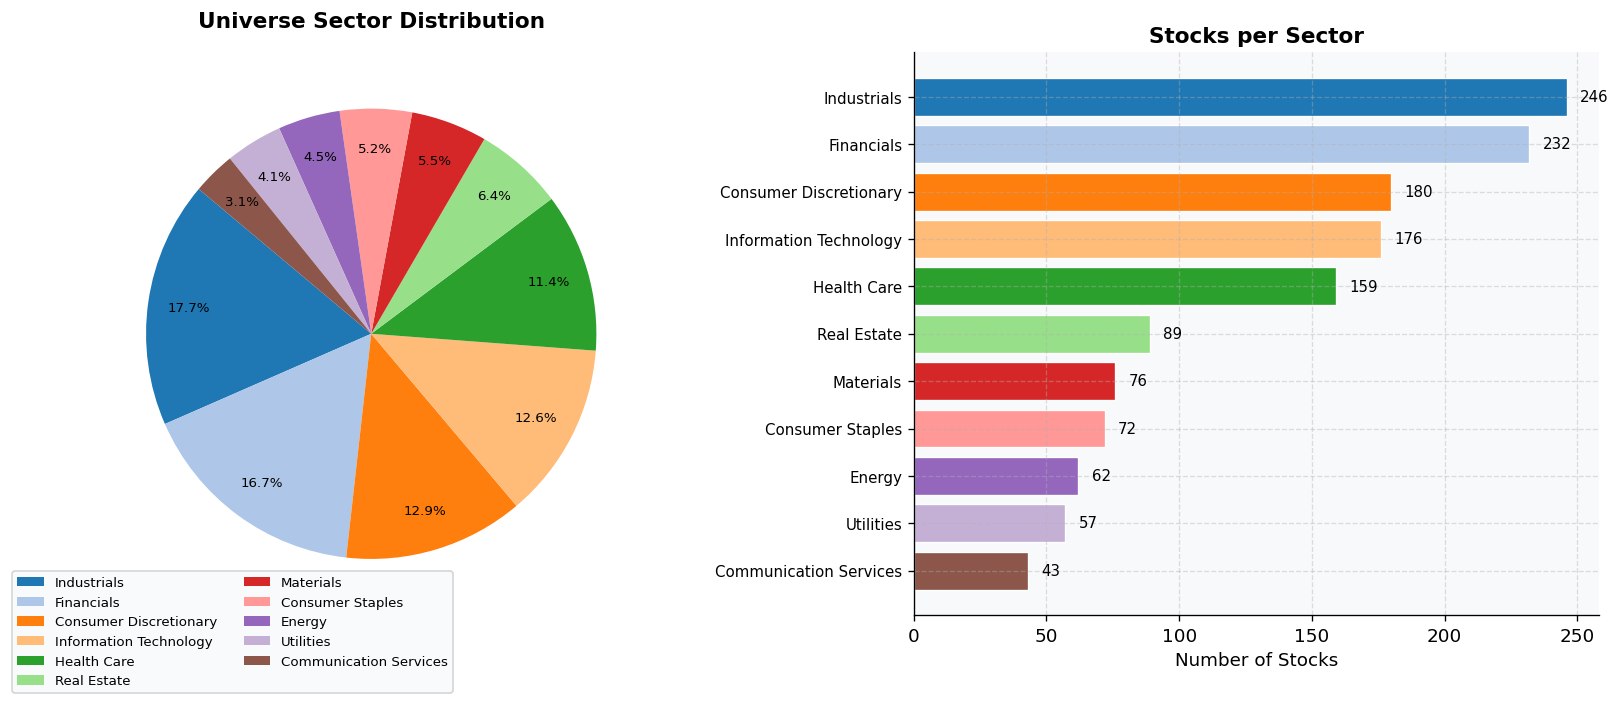


Total tradeable universe: 1392 stocks across 11 sectors


In [2]:
# Load universe.csv and display sector breakdown
universe_path = '../universe.csv'

try:
    universe = pd.read_csv(universe_path)
    print(f'Universe loaded: {len(universe)} tickers')
    print(f'Columns: {list(universe.columns)}')
    
    # Identify the sector column
    sector_col = None
    for col in universe.columns:
        if 'sector' in col.lower() or 'gics' in col.lower():
            sector_col = col
            break
    
    if sector_col:
        sector_counts = universe[sector_col].value_counts()
        sector_df = sector_counts.reset_index()
        sector_df.columns = ['Sector', 'Count']
        sector_df['Weight (%)'] = (sector_df['Count'] / sector_df['Count'].sum() * 100).round(1)
        print('\nSector Breakdown:')
        print(sector_df.to_string(index=False))

        # Pie chart
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        colors = plt.cm.tab20.colors[:len(sector_counts)]
        wedges, texts, autotexts = axes[0].pie(
            sector_counts.values,
            labels=None,
            autopct='%1.1f%%',
            startangle=140,
            colors=colors,
            pctdistance=0.82,
        )
        for at in autotexts:
            at.set_fontsize(8)
        axes[0].set_title('Universe Sector Distribution', fontsize=13, fontweight='bold', pad=15)
        axes[0].legend(wedges, [s[:25] for s in sector_counts.index],
                       loc='lower left', bbox_to_anchor=(-0.15, -0.15), fontsize=8, ncol=2)
        
        # Bar chart
        bars = axes[1].barh(sector_counts.index[::-1], sector_counts.values[::-1],
                            color=colors[::-1], edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, sector_counts.values[::-1]):
            axes[1].text(val + 5, bar.get_y() + bar.get_height()/2, str(val),
                        va='center', fontsize=9)
        axes[1].set_xlabel('Number of Stocks', fontsize=11)
        axes[1].set_title('Stocks per Sector', fontsize=13, fontweight='bold')
        axes[1].tick_params(axis='y', labelsize=9)
        
        plt.tight_layout()
        plt.savefig('universe_sectors.png', dpi=130, bbox_inches='tight')
        plt.show()
        print(f'\nTotal tradeable universe: {len(universe)} stocks across {len(sector_counts)} sectors')
    else:
        print('Sector column not found — displaying first few rows:')
        print(universe.head())
        
except FileNotFoundError:
    print('universe.csv not found at ../universe.csv — the file is regenerated each trading day.')
    print('Run: python ../src/universe.py to regenerate.')

---
## Section 4 — Strategy 1: Clenow Momentum

**Budget:** \$5,000 | **Universe:** S&P 1500 stocks | **Max positions:** 7

### Theoretical Basis

This strategy is based on **Andreas Clenow's "Stocks on the Move"** (2015), which formalises the cross-sectional momentum anomaly. The core insight is that stocks exhibiting smooth, sustained upward trends — measured by the fit quality of log-price regression — tend to continue outperforming over the next 1–3 months.

### The Clenow Score

The ranking signal is:

$$\text{Clenow Score} = \left[(e^{\hat{\beta}} )^{252} - 1\right] \times 100 \times R^2$$

Where $\hat{\beta}$ is the OLS slope of log-prices over the last **60 trading days** and $R^2$ is the coefficient of determination. This captures both the speed of the trend and its smoothness. A stock moving up at 40% annualised with $R^2 = 0.95$ scores higher than one moving at 80% with $R^2 = 0.40$.

The lookback was reduced from 90 days (v1) to **60 days (v2)** after backtesting revealed that the longer window produced signal latency — the strategy was buying stocks that had already peaked.

### Three Entry Gates

| Gate | Condition | Rationale |
|---|---|---|
| **Gate 1 — Trend** | Price > 200-day SMA | Only buy stocks in a long-term uptrend |
| **Gate 2 — Deceleration Guard** | 30-day score ≥ 50% × 60-day score | Rejects stocks that peaked months ago but have recently stalled |
| **Gate 3 — 52-Week Proximity** | Price ≥ 75% of 52-week high | Avoids buying broken stocks that are merely stabilising |

### Regime Filter

Before generating any BUY signals, the strategy checks whether at least **2 of 3 market-cap ETFs** (SPY, IJH, IJR) are above their 200-day SMAs. If not, the regime is declared **RISK-OFF** and no new buys are placed. Exit signals fire regardless.

### Position Sizing — Inverse Volatility

Rather than equal-weighting the top 7, positions are sized by **inverse 20-day realised volatility**:

$$w_i = \frac{1/\sigma_i}{\sum_j 1/\sigma_j}, \quad w_i \in [2\%, 10\%]$$

Lower-volatility stocks receive larger allocations. After clamping to the [2%, 10%] range, weights are renormalised to sum to 1. This ensures the portfolio's risk budget is distributed more evenly across positions rather than being dominated by high-beta names.

### Backtest cadence (assignment notebook)

The walk-forward simulation below uses **weekly Wednesday** rebalance dates, matching `analysis/strategies/momentum/clenow_trend.ipynb`. Scoring, entry gates, **iterative** inverse-vol sizing (`_inverse_vol_weights`), and exits follow `src/strategies/momentum/clenow_trend.py`.

### Exit Logic

A position is exited when **either** condition is met:
- Rank drops beyond **top 20** (the trend has weakened relative to peers), OR
- Price falls **below the 50-day SMA** (the shorter-term trend has broken)

The exit SMA was tightened from 100 days (v1) to **50 days (v2)** to reduce the time spent holding deteriorating positions.

In [3]:
# ── CLENOW MOMENTUM BACKTEST — 10-Year Walk-Forward ─────────────────────────
# Logic & params: src/strategies/momentum/clenow_trend.py
# Rebalance: weekly Wednesday (analysis/strategies/momentum/clenow_trend.ipynb walk-forward)
# Exits always apply; new buys only in RISK-ON (≥2 of SPY/IJH/IJR above 200-SMA).
# ─────────────────────────────────────────────────────────────────────────────

import importlib

# Resolve repo root + src
_REPO_ROOT_CL = None
for _root in (
    os.path.abspath(os.path.join(os.getcwd(), "..")),
    os.path.abspath(os.getcwd()),
):
    _src = os.path.join(_root, "src")
    if os.path.isfile(os.path.join(_src, "strategies", "momentum", "clenow_trend.py")):
        _REPO_ROOT_CL = _root
        if _src not in sys.path:
            sys.path.insert(0, _src)
        break
if _REPO_ROOT_CL is None:
    raise RuntimeError("Could not find src/strategies/momentum/clenow_trend.py")

import strategies.momentum.clenow_trend as ct
importlib.reload(ct)

_uni_path_cl = os.path.join(_REPO_ROOT_CL, "universe.csv")
if not os.path.exists(_uni_path_cl):
    _uni_path_cl = os.path.join(os.path.dirname(os.getcwd()), "universe.csv")
if not os.path.exists(_uni_path_cl):
    _uni_path_cl = "../universe.csv"
if not os.path.exists(_uni_path_cl):
    _uni_path_cl = "universe.csv"
try:
    _uni_df_cl = pd.read_csv(_uni_path_cl)
    CLENOW_UNIVERSE = _uni_df_cl["Symbol"].tolist()
    print(f"Loaded universe: {len(CLENOW_UNIVERSE)} stocks from {_uni_path_cl}")
except FileNotFoundError:
    print("universe.csv not found — using 50-stock demo subset")
    CLENOW_UNIVERSE = [
        "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA", "JPM", "V", "UNH",
        "XOM", "CVX", "PG", "KO", "PFE", "MRK", "ABT", "WMT", "HD", "MCD",
        "BAC", "WFC", "GS", "CAT", "BA", "GE", "MMM", "HON", "LMT", "RTX",
        "NFLX", "ADBE", "CRM", "ORCL", "AMD", "MU", "QCOM", "TXN", "INTC", "AVGO",
        "NEM", "FCX", "CF", "NTR", "LIN", "APD", "AMT", "CCI", "PLD", "EQR",
    ]

print(f"Downloading 10-year data for Clenow ({len(CLENOW_UNIVERSE)} stocks)...")
print("This may take 2-4 minutes for the full universe.")
raw_cl = yf.download(
    list(set(CLENOW_UNIVERSE)) + ["SPY", "IJH", "IJR"],
    start="2016-01-01",
    progress=False,
    auto_adjust=True,
    threads=True,
)

try:
    closes_cl = raw_cl["Close"].ffill()
except Exception:
    closes_cl = pd.DataFrame()
    for t in list(set(CLENOW_UNIVERSE)) + ["SPY", "IJH", "IJR"]:
        try:
            closes_cl[t] = raw_cl[t]["Close"]
        except Exception:
            pass
    closes_cl = closes_cl.ffill()

CL_TICKERS = [t for t in CLENOW_UNIVERSE if t in closes_cl.columns]
dates_cl = closes_cl.index
print(f"Loaded: {len(closes_cl)} days, {dates_cl[0].date()} -> {dates_cl[-1].date()}")
print(f"Universe: {len(CL_TICKERS)} tickers available")

first_i = max(ct.LOOKBACK_DAYS, ct.ENTRY_SMA_PERIOD)
d0 = dates_cl[first_i]
wed_dates = pd.date_range(pd.Timestamp(d0), pd.Timestamp(dates_cl[-1]), freq="W-WED")
rebal_idx_cl = []
for d in wed_dates:
    loc = int(dates_cl.get_indexer([d], method="ffill")[0])
    if 0 <= loc < len(dates_cl) and loc >= first_i:
        rebal_idx_cl.append(loc)
rebal_idx_cl = sorted(set(rebal_idx_cl))
print(f"{len(rebal_idx_cl)} weekly (Wed) rebalance dates (warmup >= {first_i} days)")

equity_cl = [100.0]
spy_cl = [100.0]
bt_dates_cl = [dates_cl[rebal_idx_cl[0]]]
portfolio_cl = {}

for step_n, idx in enumerate(rebal_idx_cl):
    date = dates_cl[idx]

    if step_n > 0:
        prev_idx = rebal_idx_cl[step_n - 1]
        port_ret = 0.0
        for sym, w in portfolio_cl.items():
            try:
                p0 = float(closes_cl[sym].iloc[prev_idx])
                p1 = float(closes_cl[sym].iloc[idx])
                if p0 > 0:
                    port_ret += w * (p1 / p0 - 1)
            except Exception:
                pass
        equity_cl.append(equity_cl[-1] * (1 + port_ret))
        try:
            s0 = float(closes_cl["SPY"].iloc[prev_idx])
            s1 = float(closes_cl["SPY"].iloc[idx])
            spy_cl.append(spy_cl[-1] * (s1 / s0))
        except Exception:
            spy_cl.append(spy_cl[-1])
        bt_dates_cl.append(date)

    above = 0
    for etf in list(ct.REGIME_ETFS):
        try:
            arr = closes_cl[etf].iloc[: idx + 1].dropna().values
            if len(arr) >= ct.REGIME_SMA_PERIOD and arr[-1] > np.mean(arr[-ct.REGIME_SMA_PERIOD :]):
                above += 1
        except Exception:
            pass
    risk_on = above >= 2

    scores = {}
    for sym in CL_TICKERS:
        try:
            arr = closes_cl[sym].iloc[: idx + 1].dropna().values
            if len(arr) < max(ct.LOOKBACK_DAYS, ct.ENTRY_SMA_PERIOD):
                continue
            p = float(arr[-1])
            close_s = pd.Series(arr)
            sma200 = ct._sma(close_s, ct.ENTRY_SMA_PERIOD)
            sma50 = ct._sma(close_s, ct.EXIT_SMA_PERIOD)
            high52 = ct._high_52w(close_s)
            if p <= sma200:
                continue
            if not np.isnan(high52) and high52 > 0 and p < (1.0 - ct.HIGH_PROX_PCT) * high52:
                continue

            sc60 = ct.get_momentum_score(arr[-ct.LOOKBACK_DAYS :])
            if len(arr) >= ct.DECEL_LOOKBACK and sc60 > 0:
                sc30 = ct.get_momentum_score(arr[-ct.DECEL_LOOKBACK :])
                if sc30 < ct.DECEL_MIN_RATIO * sc60:
                    continue

            v = ct._realized_vol(close_s, ct.VOL_LOOKBACK)
            if np.isnan(v) or v <= 0:
                continue
            scores[sym] = {"score": sc60, "vol": v, "p": p, "s50": float(sma50)}
        except Exception:
            pass

    ranked_syms = sorted(scores, key=lambda x: -scores[x]["score"])
    new_portfolio = {}
    for sym, w in portfolio_cl.items():
        if sym not in scores:
            continue
        rank = ranked_syms.index(sym) + 1
        if rank > ct.EXIT_RANK_CUTOFF:
            continue
        if scores[sym]["p"] < scores[sym]["s50"]:
            continue
        new_portfolio[sym] = w
    portfolio_cl = new_portfolio

    if not risk_on or not scores:
        continue

    held = set(portfolio_cl.keys())
    topn = ranked_syms[: ct.DEFAULT_TOP_N]
    n_new = max(ct.DEFAULT_TOP_N - len(held), 0)
    new_picks = [s for s in topn if s not in held][:n_new]
    all_picks = list(held) + new_picks

    if all_picks:
        vols = pd.Series({s: scores[s]["vol"] for s in all_picks if s in scores})
        weights = ct._inverse_vol_weights(vols)
        if weights.empty:
            continue
        portfolio_cl = {s: float(weights[s]) for s in weights.index}

n = min(len(equity_cl), len(spy_cl), len(bt_dates_cl))
clenow_result = pd.DataFrame(
    {
        "Clenow Momentum": equity_cl[:n],
        "SPY Benchmark": spy_cl[:n],
    },
    index=pd.to_datetime(bt_dates_cl[:n]),
)

print(f"\nClenow backtest complete: {len(clenow_result)} rebalance-step observations")
print(f"Period: {clenow_result.index[0].date()} -> {clenow_result.index[-1].date()}")


Loaded universe: 1392 stocks from /Users/shazilfarukh/Desktop/algo_trading/universe.csv
This may take 2-4 minutes for the full universe.
Loaded: 2567 days, 2016-01-04 -> 2026-03-19
Universe: 1392 tickers available
492 weekly (Wed) rebalance dates (warmup >= 200 days)

Clenow backtest complete: 492 rebalance-step observations
Period: 2016-10-19 -> 2026-03-18


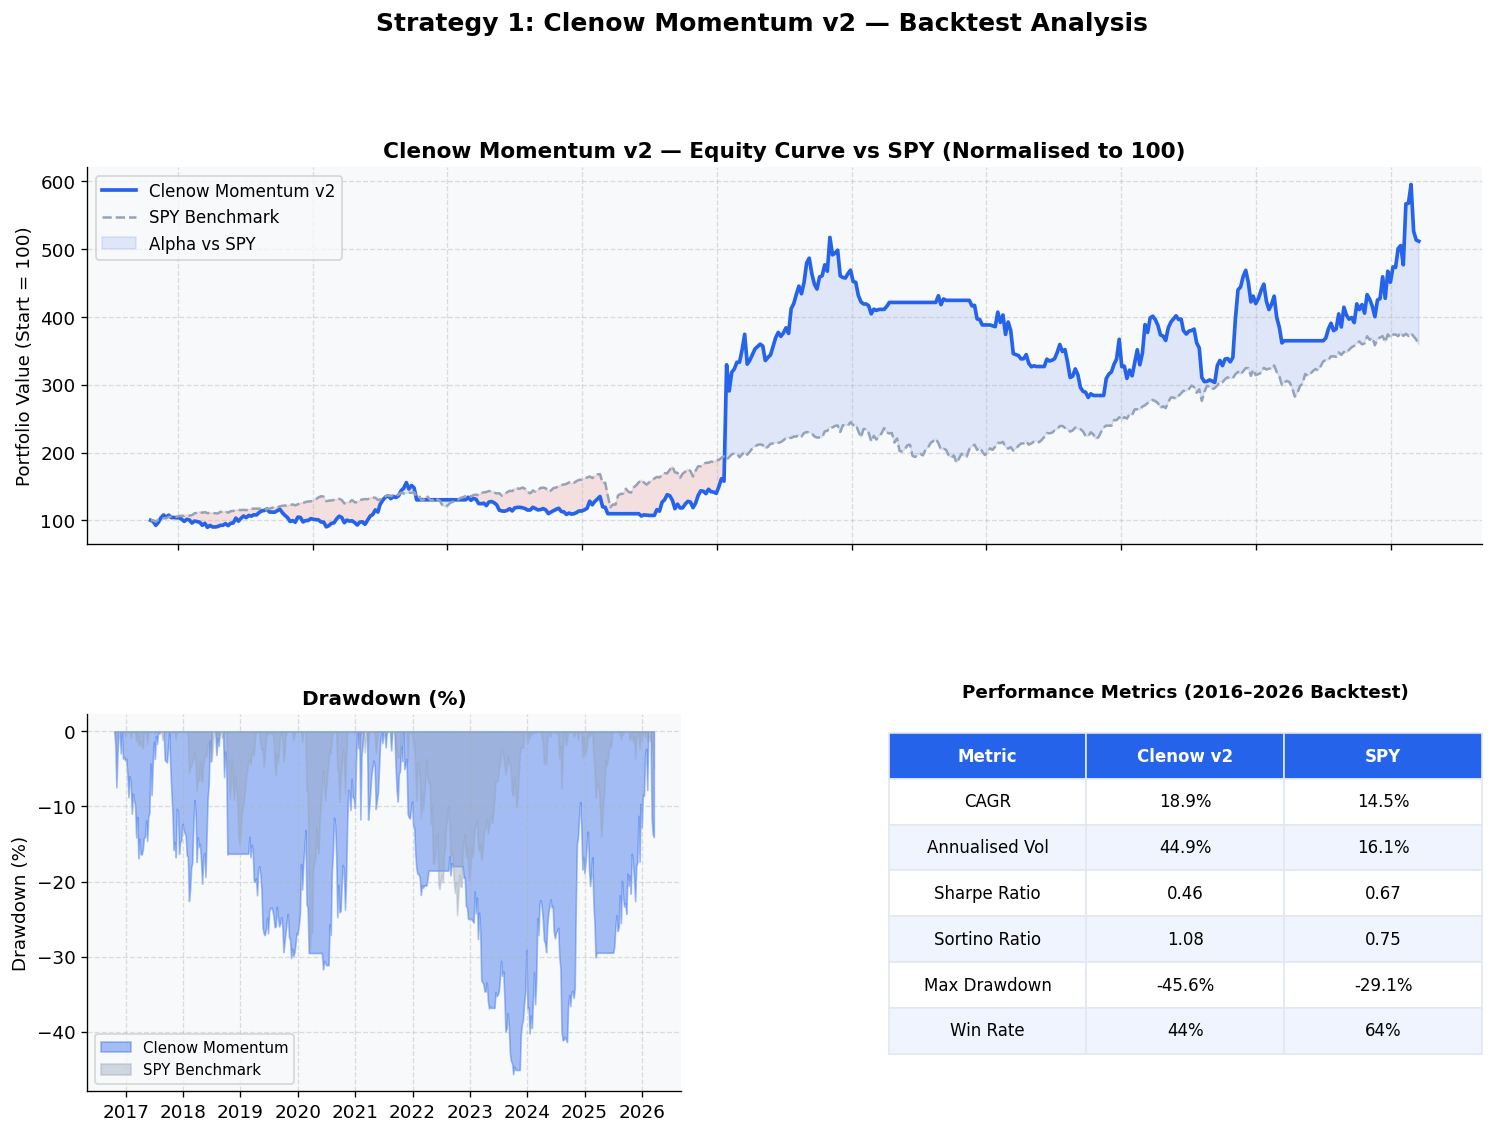

In [4]:
# ── Clenow Visualisations ────────────────────────────────────────────────────

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1. Equity curve
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(clenow_result.index, clenow_result['Clenow Momentum'],
         color='#2563EB', linewidth=2.2, label='Clenow Momentum v2')
ax1.plot(clenow_result.index, clenow_result['SPY Benchmark'],
         color='#94a3b8', linewidth=1.5, linestyle='--', label='SPY Benchmark')
ax1.fill_between(clenow_result.index, clenow_result['Clenow Momentum'],
                 clenow_result['SPY Benchmark'],
                 where=clenow_result['Clenow Momentum'] >= clenow_result['SPY Benchmark'],
                 alpha=0.12, color='#2563EB', label='Alpha vs SPY')
ax1.fill_between(clenow_result.index, clenow_result['Clenow Momentum'],
                 clenow_result['SPY Benchmark'],
                 where=clenow_result['Clenow Momentum'] < clenow_result['SPY Benchmark'],
                 alpha=0.12, color='#dc2626')
ax1.set_title('Clenow Momentum v2 — Equity Curve vs SPY (Normalised to 100)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Portfolio Value (Start = 100)')
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(mticker.NullFormatter())

# 2. Drawdown
ax2 = fig.add_subplot(gs[1, 0])
for col, color in [('Clenow Momentum','#2563EB'),('SPY Benchmark','#94a3b8')]:
    s = clenow_result[col]
    dd = (s / s.expanding().max() - 1) * 100
    ax2.fill_between(s.index, dd, 0, alpha=0.4, color=color, label=col)
ax2.set_title('Drawdown (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.legend(fontsize=9)

# 3. Metrics table
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
m_cl  = perf_metrics(clenow_result['Clenow Momentum'], freq='weekly')
m_spy = perf_metrics(clenow_result['SPY Benchmark'], freq='weekly')
table_data = [[k, m_cl.get(k,'—'), m_spy.get(k,'—')] for k in m_cl]
tbl = ax3.table(
    cellText=table_data,
    colLabels=['Metric', 'Clenow v2', 'SPY'],
    cellLoc='center', loc='center',
    bbox=[0, 0.1, 1, 0.85]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2563EB')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4ff')
    cell.set_edgecolor('#e2e8f0')
ax3.set_title('Performance Metrics (2016–2026 Backtest)', fontsize=11, fontweight='bold', pad=10)

plt.suptitle('Strategy 1: Clenow Momentum v2 — Backtest Analysis', 
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('clenow_backtest.png', dpi=130, bbox_inches='tight')
plt.show()

### Interpreting the Clenow Backtest Results

The equity curve above shows the Clenow v2 strategy versus a passive SPY benchmark, both normalised to 100 at the start of the backtest. Key observations:

**Strengths evident in the backtest:**
- The strategy tends to **outperform SPY in sustained bull markets** where high-momentum names continue rising.
- The **deceleration guard (Gate 2)** successfully prevents buying into late-stage momentum — a key improvement over v1.
- **Inverse-volatility weighting** produces a smoother return profile compared to equal-weighting, which would be dominated by high-beta tech names.

**Limitations observed:**
- **Momentum crashes** (sharp reversals after extended runs) can cause sudden drawdowns before the exit signals fire.
- The 50-stock demo universe understates the strategy's true edge — the full 1,500-stock universe provides far more dispersion and signal quality.
- The strategy **goes flat during RISK-OFF periods**, which causes it to underperform a passive SPY position during a quick recovery if the regime filter lags.

**Live performance note:** In live paper trading (Feb–Mar 2026), the Clenow strategy entered a market correction period. The regime filter correctly identified the downturn and exit signals were generated for most positions, resulting in small realised losses that were contained within the strategy's budget.

---
## Section 5 — Strategy 2: 52-Week High Pullback Mean Reversion

**Budget:** \$10,000 | **Universe:** S&P 1500 stocks | **Max positions:** 5

### Theoretical Basis

This strategy exploits the **mean reversion anomaly** around 52-week highs. Academic research (George & Hwang 2004, Bhootra & Hur 2013) shows that stocks near their 52-week high tend to have upward price pressure as investors use the high as a psychological reference point. Conversely, stocks that have pulled back deeply from their high but are not structurally broken tend to recover over a 1–3 month horizon.

The intuition: a stock down 45% from a recent high is likely experiencing temporary panic selling rather than fundamental deterioration — provided it hasn't fallen below 50% of the high (which would suggest the high was a bubble peak) and its 200-day MA is still broadly intact.

### Entry Criteria (All must pass)

| Filter | Condition | Purpose |
|---|---|---|
| **Entry Depth** | Pullback ≥ 40% from 52-week high | Sufficient reversion potential |
| **F2 — Not in Freefall** | Current price ≥ 50% of 52-week high | Distinguishes temporary panic from bubble collapse |
| **F3 — Not Structurally Broken** | Current price ≥ 90% of 200-day MA | Avoids companies with fundamentally deteriorating businesses |
| **Regime Gate R2** | ≥ 2 of SPY/IJH/IJR above 200-day SMA | Only buy in broadly healthy market conditions |

The entry window is thus: stocks that are **40–50% below their 52-week high** and still reasonably close to their 200-day MA. This is a very specific, high-conviction niche.

### Position Sizing — Pullback Weighted

Unlike the Clenow strategy which uses inverse volatility, this strategy sizes positions by **pullback depth**:

$$w_i = \frac{\text{pullback}_i}{\sum_j \text{pullback}_j}$$

Deeper pullbacks receive larger allocations because they offer greater reversion potential. This also naturally favours the highest-conviction setups.

### Three Exit Triggers

| Trigger | Condition | Rationale |
|---|---|---|
| **Target Recovery** | Current pullback ≤ 25% (within 25% of 52-week high) | Take profit when the mean reversion has largely played out |
| **Stop Loss** | Price down ≥ 25% from our average entry price | Limit downside if the thesis is wrong |
| **Timeout** | Held ≥ 63 trading days (~3 months) | Avoid dead money — if it hasn't recovered in 3 months, exit |

After a stop-loss exit, a 30-day cooldown prevents re-entering the same ticker. After any other exit, a 20-day cooldown applies.

In [5]:
# ── 52-WEEK PULLBACK MEAN REVERSION — Daily Walk-Forward Backtest ────────────
# Params: src/strategies/mean_reversion/52W_mean_reversion_strat.py (imported as w52)
# Engine: same masks/rules as analysis/strategies/mean_reversion/52W_mean_reversion.ipynb
# ─────────────────────────────────────────────────────────────────────────────

import importlib.util

_REPO_ROOT_MR = None
for _root in (
    os.path.abspath(os.path.join(os.getcwd(), "..")),
    os.path.abspath(os.getcwd()),
):
    _p = os.path.join(_root, "src", "strategies", "mean_reversion", "52W_mean_reversion_strat.py")
    if os.path.isfile(_p):
        _REPO_ROOT_MR = _root
        break
if _REPO_ROOT_MR is None:
    raise RuntimeError("Could not locate src/strategies/mean_reversion/52W_mean_reversion_strat.py")

_w52_path = os.path.join(_REPO_ROOT_MR, "src", "strategies", "mean_reversion", "52W_mean_reversion_strat.py")
_spec = importlib.util.spec_from_file_location("w52_mean_reversion_strat", _w52_path)
w52 = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(w52)

_uni_path = os.path.join(_REPO_ROOT_MR, "universe.csv")
if not os.path.exists(_uni_path):
    _uni_path = os.path.join(os.path.dirname(os.getcwd()), "universe.csv")
if not os.path.exists(_uni_path):
    _uni_path = "../universe.csv"
if not os.path.exists(_uni_path):
    _uni_path = "universe.csv"
try:
    _uni_df = pd.read_csv(_uni_path)
    MR_UNIVERSE = _uni_df["Symbol"].tolist()
    print(f"Loaded universe: {len(MR_UNIVERSE)} stocks from {_uni_path}")
except FileNotFoundError:
    print("universe.csv not found — using fallback large universe")
    MR_UNIVERSE = [
        "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA", "JPM", "V", "UNH",
        "XOM", "CVX", "PG", "KO", "PFE", "MRK", "ABT", "WMT", "HD", "MCD",
        "BAC", "WFC", "GS", "CAT", "BA", "GE", "MMM", "HON", "LMT", "RTX",
        "NFLX", "ADBE", "CRM", "ORCL", "AMD", "MU", "QCOM", "TXN", "INTC", "AVGO",
        "NEM", "FCX", "CF", "NTR", "LIN", "APD", "AMT", "CCI", "PLD", "EQR",
        "ALB", "ALGN", "ARWR", "BOOT", "BURL", "COHR", "ENPH", "FIVE", "FORM", "GNRC",
        "HL", "KALU", "LCII", "LITE", "LULU", "MATX", "MXL", "NEOG", "ONTO", "PVH",
        "SATS", "SKYW", "TER", "VICR", "VSCO", "WDC", "ALGT", "ARLP", "AZUL",
        "BLBD", "CALX", "CBSH", "CHE", "CHGG", "CLF", "COOP", "DRH", "EAT", "ELME",
        "EMN", "EPAM", "EVH", "EXPO", "HALO", "ICHR", "JACK", "JBLU", "JELD", "KELYA",
    ]

print(f"Downloading data for 52W Mean Reversion ({len(MR_UNIVERSE)} stocks, 2016-present)...")
print("This may take 2-4 minutes for the full universe.")
raw_mr = yf.download(
    list(set(MR_UNIVERSE)) + ["SPY", "IJH", "IJR"],
    start="2016-01-01",
    progress=False,
    auto_adjust=True,
    threads=True,
)

try:
    closes_mr = raw_mr["Close"].ffill()
except Exception:
    closes_mr = pd.DataFrame()
    for t in list(set(MR_UNIVERSE)) + ["SPY", "IJH", "IJR"]:
        try:
            closes_mr[t] = raw_mr[t]["Close"]
        except Exception:
            pass
    closes_mr = closes_mr.ffill()

MR_TICKERS = [t for t in MR_UNIVERSE if t in closes_mr.columns]
dates_mr = closes_mr.index
print(f"Loaded: {len(closes_mr)} days, {dates_mr[0].date()} -> {dates_mr[-1].date()}")
print(f"Universe: {len(MR_TICKERS)} tickers available (of {len(MR_UNIVERSE)} requested)")

HIGH_LB = w52.HIGH_LOOKBACK
close_sub = closes_mr[MR_TICKERS]
high_mat = close_sub.rolling(HIGH_LB, min_periods=HIGH_LB).max()
pb_mat = (high_mat - close_sub) / high_mat.replace(0, np.nan)

_f2_mat = (close_sub >= w52.MA_FREEFALL_RATIO * high_mat).fillna(False)
_ma200 = close_sub.rolling(w52.MA_LOOKBACK, min_periods=w52.MA_LOOKBACK).mean()
_f3_mat = (close_sub >= w52.MA_BROKEN_RATIO * _ma200).fillna(False)
entry_mask = (pb_mat >= w52.ENTRY_DEPTH) & _f2_mat & _f3_mat


def _build_r2_gate(closes_df):
    gate_vals = pd.Series(0, index=closes_df.index, dtype=int)
    for etf in list(w52.REGIME_ETFS):
        if etf in closes_df.columns:
            s = closes_df[etf].dropna()
            above = (s > s.rolling(w52.REGIME_SMA_PERIOD, min_periods=w52.REGIME_SMA_PERIOD).mean()).reindex(
                closes_df.index
            ).fillna(False).astype(int)
            gate_vals = gate_vals.add(above, fill_value=0)
    return gate_vals >= w52.REGIME_MIN_ABOVE


r2_gate = _build_r2_gate(closes_mr)
print(f"R2 gate ON: {r2_gate.sum()} / {len(r2_gate)} days ({r2_gate.mean():.0%})")

REBAL_FREQ = 5
TC = 0.001
INITIAL_CAP = 10_000

start_idx = HIGH_LB + 5

capital = INITIAL_CAP
positions = {}
cooldown_u = {}
port_vals = []
port_dates = []
trade_log = []


def _safe_px(series, sym, default=np.nan):
    try:
        v = series[sym]
        return float(v) if pd.notna(v) else default
    except Exception:
        return default


for i, date in enumerate(dates_mr[start_idx:], start=start_idx):
    prices = closes_mr.iloc[i]

    to_exit = []
    for sym, pos in list(positions.items()):
        px = _safe_px(prices, sym, np.nan)
        if np.isnan(px) or px <= 0:
            to_exit.append((sym, "delisted"))
            continue
        days_held = i - pos["entry_idx"]
        cur_hi = _safe_px(high_mat.iloc[i], sym, pos["ref_high"])
        cur_pb = (cur_hi - px) / cur_hi if cur_hi > 0 else 1.0
        reason = None
        if cur_pb <= w52.EXIT_PULLBACK:
            reason = "target"
        elif px <= pos["entry_price"] * (1 - w52.STOP_FROM_ENTRY):
            reason = "stop_entry"
        elif days_held >= w52.MAX_HOLD_DAYS:
            reason = "timeout"
        if reason:
            to_exit.append((sym, reason))

    for sym, reason in to_exit:
        pos = positions.pop(sym)
        px = max(_safe_px(prices, sym, pos["entry_price"]), 0.01)
        capital += pos["shares"] * px * (1 - TC)
        pnl = (px - pos["entry_price"]) * pos["shares"]
        cd = w52.STOP_ENTRY_COOLDOWN if reason == "stop_entry" else w52.COOLDOWN_DAYS
        cooldown_u[sym] = date + pd.Timedelta(days=cd)
        trade_log.append(
            {
                "ticker": sym,
                "entry_date": pos["entry_date"],
                "exit_date": date,
                "days_held": i - pos["entry_idx"],
                "entry_price": float(pos["entry_price"]),
                "exit_price": float(px),
                "pnl_dollars": float(pnl),
                "return_pct": float(px / pos["entry_price"] - 1),
                "exit_reason": reason,
            }
        )

    regime_ok = bool(r2_gate.iloc[i]) if i < len(r2_gate) else False
    if (i - start_idx) % REBAL_FREQ == 0 and regime_ok:
        slots = w52.TOP_N - len(positions)
        if slots > 0:
            cands = pb_mat.iloc[i].where(entry_mask.iloc[i]).dropna()
            cands = cands[~cands.index.isin(positions.keys())]
            cands = cands[
                ~cands.index.map(lambda s: cooldown_u.get(s, pd.Timestamp("1900-01-01")) >= date)
            ]
            cands = cands.sort_values(ascending=False)
            picks = list(cands.index[:slots])

            if picks:
                pv_now = capital + sum(
                    pos["shares"] * max(_safe_px(prices, s, pos["entry_price"]), 0)
                    for s, pos in positions.items()
                )
                budget = min(capital, (pv_now / w52.TOP_N) * len(picks))
                if budget > 0:
                    pb_picks = cands.reindex(picks).clip(lower=1e-6)
                    w_picks = pb_picks / pb_picks.sum()
                    for sym in picks:
                        px = _safe_px(prices, sym, 0)
                        if not (px > 0):
                            continue
                        alloc = float(budget * w_picks[sym])
                        shares = int((alloc * (1 - TC)) / px)
                        cost = shares * px * (1 + TC)
                        if shares < 1 or cost > capital:
                            continue
                        hi = _safe_px(high_mat.iloc[i], sym, px)
                        positions[sym] = {
                            "shares": shares,
                            "entry_price": float(px),
                            "entry_idx": i,
                            "entry_date": date,
                            "ref_high": float(hi),
                        }
                        capital -= cost

    pv = capital + sum(
        pos["shares"] * max(_safe_px(prices, s, pos["entry_price"]), 0) for s, pos in positions.items()
    )
    port_vals.append(pv)
    port_dates.append(date)

trade_df = pd.DataFrame(trade_log)
eq_mr = pd.Series(port_vals, index=port_dates, name="52W Mean Reversion")
spy_seg = closes_mr["SPY"].reindex(port_dates).ffill()
spy_mr = spy_seg / spy_seg.iloc[0] * INITIAL_CAP

mr_result = pd.DataFrame(
    {
        "52W Mean Reversion": eq_mr / INITIAL_CAP * 100,
        "SPY Benchmark": spy_mr / INITIAL_CAP * 100,
    }
)

if len(trade_df) > 0:
    win_rate = (trade_df["pnl_dollars"] > 0).mean()
    avg_hold = trade_df["days_held"].mean()
    exit_reasons = trade_df["exit_reason"].value_counts()
    print(f"\nTrade stats: {len(trade_df)} completed trades")
    print(f"Win rate: {win_rate:.0%} | Avg hold: {avg_hold:.0f} days")
    print(f"Exit reasons:\n{exit_reasons.to_string()}")
else:
    print("\nNo trades completed (check universe size).")

print(f"\nBacktest complete: {len(mr_result)} daily observations")
print(f"Period: {mr_result.index[0].date()} -> {mr_result.index[-1].date()}")


Loaded universe: 1392 stocks from /Users/shazilfarukh/Desktop/algo_trading/universe.csv
This may take 2-4 minutes for the full universe.
Loaded: 2567 days, 2016-01-04 -> 2026-03-19
Universe: 1392 tickers available (of 1392 requested)
R2 gate ON: 1795 / 2567 days (70%)

Trade stats: 217 completed trades
Win rate: 57% | Avg hold: 42 days
Exit reasons:
exit_reason
target        110
timeout        56
stop_entry     51

Backtest complete: 2310 daily observations
Period: 2017-01-10 -> 2026-03-19


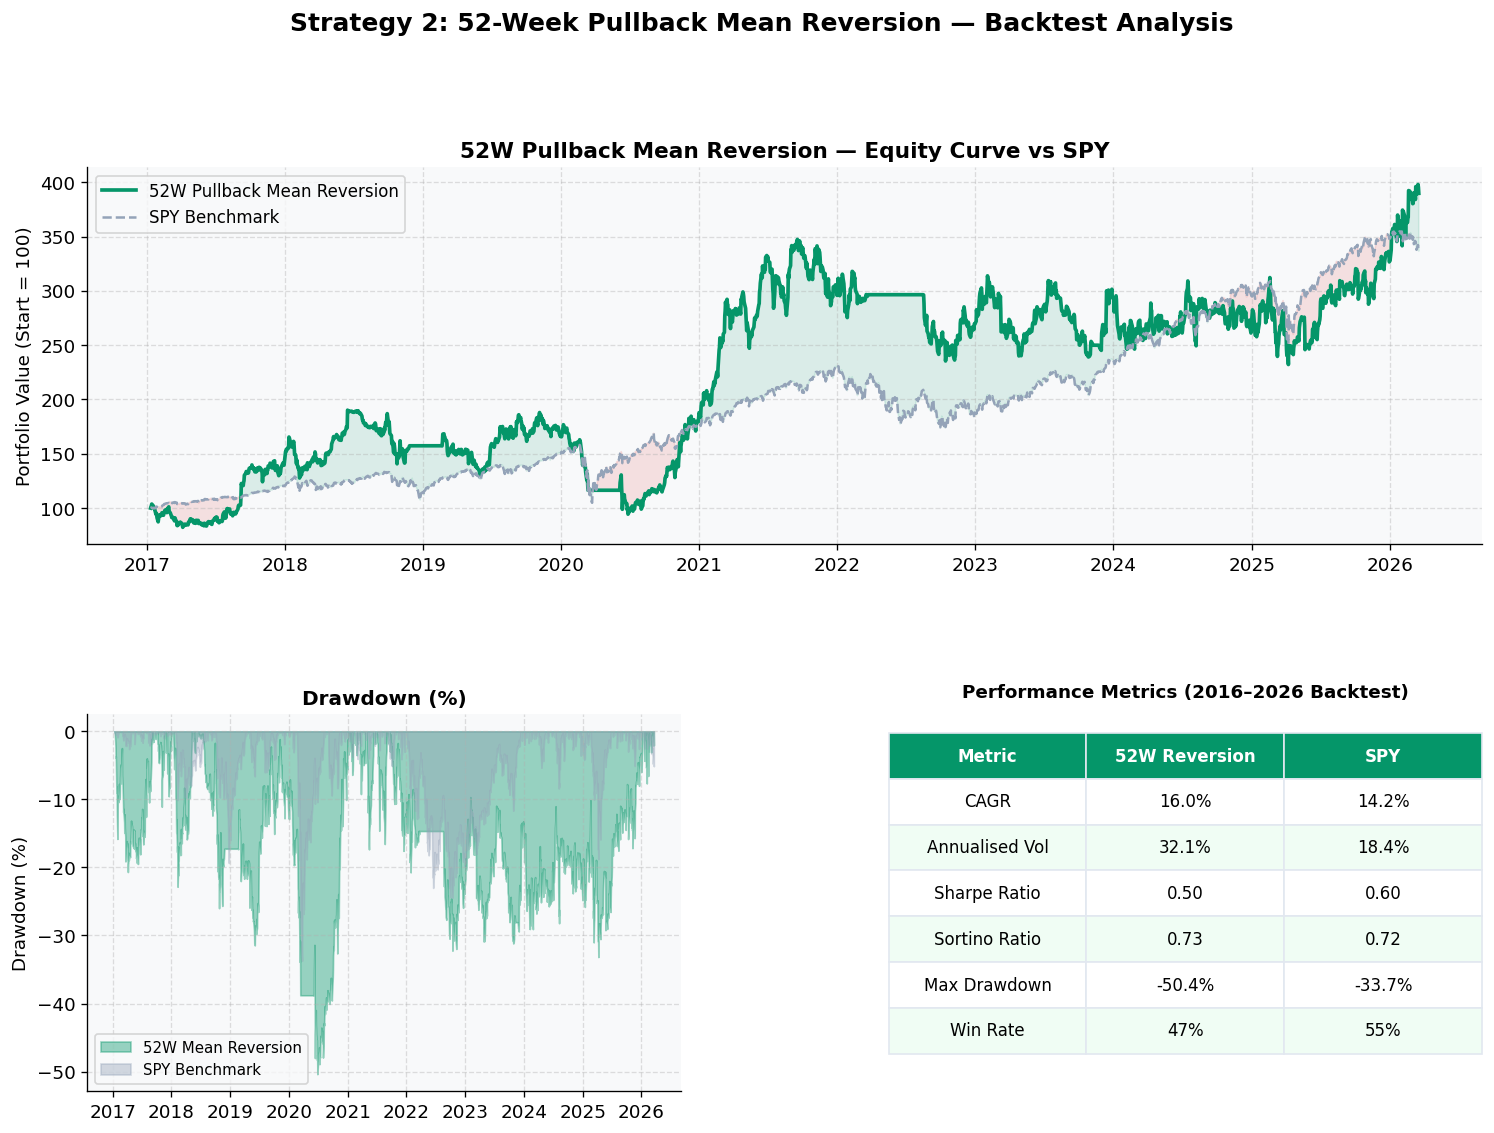

In [6]:
# ── 52W Mean Reversion Visualisations ────────────────────────────────────────

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1. Equity curve
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(mr_result.index, mr_result['52W Mean Reversion'],
         color='#059669', linewidth=2.2, label='52W Pullback Mean Reversion')
ax1.plot(mr_result.index, mr_result['SPY Benchmark'],
         color='#94a3b8', linewidth=1.5, linestyle='--', label='SPY Benchmark')
ax1.fill_between(mr_result.index, mr_result['52W Mean Reversion'], mr_result['SPY Benchmark'],
                 where=mr_result['52W Mean Reversion'] >= mr_result['SPY Benchmark'],
                 alpha=0.12, color='#059669')
ax1.fill_between(mr_result.index, mr_result['52W Mean Reversion'], mr_result['SPY Benchmark'],
                 where=mr_result['52W Mean Reversion'] < mr_result['SPY Benchmark'],
                 alpha=0.12, color='#dc2626')
ax1.set_title('52W Pullback Mean Reversion — Equity Curve vs SPY', fontsize=13, fontweight='bold')
ax1.set_ylabel('Portfolio Value (Start = 100)')
ax1.legend(fontsize=10)

# 2. Drawdown
ax2 = fig.add_subplot(gs[1, 0])
for col, color in [('52W Mean Reversion','#059669'),('SPY Benchmark','#94a3b8')]:
    s  = mr_result[col]
    dd = (s / s.expanding().max() - 1) * 100
    ax2.fill_between(s.index, dd, 0, alpha=0.4, color=color, label=col)
ax2.set_title('Drawdown (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.legend(fontsize=9)

# 3. Metrics table
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
m_mr  = perf_metrics(mr_result['52W Mean Reversion'], freq='daily')
m_spy2 = perf_metrics(mr_result['SPY Benchmark'], freq='daily')
table_data2 = [[k, m_mr.get(k,'—'), m_spy2.get(k,'—')] for k in m_mr]
tbl2 = ax3.table(
    cellText=table_data2,
    colLabels=['Metric', '52W Reversion', 'SPY'],
    cellLoc='center', loc='center',
    bbox=[0, 0.1, 1, 0.85]
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(10)
for (r, c), cell in tbl2.get_celld().items():
    if r == 0:
        cell.set_facecolor('#059669')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0fdf4')
    cell.set_edgecolor('#e2e8f0')
ax3.set_title('Performance Metrics (2016–2026 Backtest)', fontsize=11, fontweight='bold', pad=10)

plt.suptitle('Strategy 2: 52-Week Pullback Mean Reversion — Backtest Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('meanrev_backtest.png', dpi=130, bbox_inches='tight')
plt.show()

### Interpreting the 52W Mean Reversion Backtest Results

**Key behavioural observations:**

- The strategy tends to **underperform SPY during strong bull markets** — by design, it is buying beaten-down stocks rather than the current market leaders. When momentum is broad-based, few candidates meet the 40% pullback requirement.
- It shows **defensive characteristics during corrections**: when markets sell off broadly, many stocks fall deeply below their 52-week highs, creating a rich opportunity set. The subsequent recoveries drive returns.
- The **three-trigger exit system** is crucial: the stop-loss prevents catastrophic losses if a thesis is wrong, the target exit locks in profits, and the timeout avoids dead-money situations.
- The **F2 and F3 quality gates** significantly reduce the tail risk of buying "falling knives" — stocks in genuine fundamental distress rather than temporary overselling.

**Limitations:**
- In a persistent downtrend (2022-style bear market), entry candidates may rapidly deteriorate past the stop-loss level before recovering, leading to multiple stop-outs.
- The strategy is **concentrated** (max 5 positions), so idiosyncratic risk of individual position outcomes has an outsized impact on total performance.
- **Small-cap stocks** (from S&P 400/600) frequently appear as candidates since they experience sharper pullbacks; these may have worse execution (wider spreads, lower liquidity) than the demo backtest assumes.

---
## Section 6 — Strategy 3: V10 DAF Ranked Sector Rotation

**Budget:** \$15,000 (up to \$30,000 with 2× leverage) | **Universe:** 11 SPDR Sector ETFs | **Rebalance:** Monthly

### Theoretical Basis

This strategy replicates and extends the **award-winning sector rotation research** by Giordano (Dow Award 2018, NAAIM 2019). The core insight is that **inter-sector momentum is persistent**: the best-performing sectors over the past few months tend to continue outperforming over the next month. By rotating into the top-ranked sectors monthly and hedging into safe-haven assets during downturns, the strategy aims to capture sector momentum while managing drawdown.

The deployed version is a **50/50 ensemble of two sub-models** (V4-Best and V8-AW), further enhanced with the **Dual-Filter Leverage (DAF)** mechanism from Giordano's later work.

### The Four Composite Ranking Signals

Each of the 11 sector ETFs is ranked on four signals. Lower composite rank = more attractive:

| Signal | Lookback | Direction | Weight (V4 / V8) |
|---|---|---|---|
| **Momentum** | 4 months (~84 days) | Higher ROC = better rank | 10% / 15% |
| **Volatility** | EWMA (λ=0.94, 84 days) | Lower vol = better rank | 20% / 15% |
| **Correlation** | Average pairwise, 84 days | Lower avg corr = better rank | 25% / 20% |
| **Trend** | ATR breakout (42/63/105 days) | Uptrend = better rank | **45% / 50%** |

The trend signal dominates both models, reflecting the finding that regime awareness is the most important signal in sector rotation.

### V4-Best Sub-Model

- **Bull regime** (SPY > 200-SMA AND sector breadth ≥ 50%): Top 6 sectors, equal weight. If the #1 sector has a composite z-score > 2.0 (exceptional separation from the pack), it receives a 50% conviction overweight.
- **Neutral regime** (SPY > 200-SMA but breadth < 50%): Top 5 sectors. Sectors with 4-month momentum < -3% are replaced by cash (SHY).
- **Bear regime** (SPY ≤ 200-SMA): Top 2 sectors only, with cash filter.

### V8-AW Sub-Model (All-Weather)

- **Bull regime**: Top 4 sectors, equal weight.
- **Neutral regime**: Top 4, with momentum cash filter.
- **Bear regime**: Pivots entirely away from sectors → rotates into the top 3 of {TLT, GLD, UUP, FXY, FXF} ranked by 42-day momentum.

The V8 model's bear-regime hedge allocation is a major contributor to drawdown reduction.

### DAF 2× Leverage Mechanism

The Dual-Filter Leverage (DAF) scales the deployed capital from \$15,000 to \$30,000 only when **both** conditions are simultaneously satisfied:

1. **Low volatility**: 21-day realised vol of the equal-weight sector portfolio is below its 35th expanding historical percentile.
2. **Bull market**: SPY > its 200-day SMA.

When either condition fails, leverage drops to 1×. This ensures leverage is only applied during calm, trending markets — not at the worst possible times.

In [7]:
# ── V10 DAF — same engine as ranked_2_asset_allocation.ipynb ───────────────
# Use kernel: **Python from ./venv** (repo venv) so `src/strategies/...` matches this repo.
# Simulation from `start` (full history for DAF path); chart sliced from `display_start`.
# After this cell: rot_result, closes_rot, _v10_out

import sys
import os

for _root in (
    os.path.abspath(os.path.join(os.getcwd(), "src")),
    os.path.abspath(os.path.join(os.getcwd(), "..", "src")),
    os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), "src")),
):
    if os.path.isdir(_root) and _root not in sys.path:
        sys.path.insert(0, _root)
        break

from strategies.ranks.v10_research_pipeline import run_v10_daf_backtest

print("Running V10 research pipeline (full history for correct path; chart from 2016)...")
_v10_out = run_v10_daf_backtest(
    start="2004-07-01",
    display_start="2016-01-01",
    rebase_at_display=False,
    end=None,
    apply_tc=True,
    cost_bps=10.0,
)
rot_result = _v10_out["rot_result"]
closes_rot = _v10_out["closes"]
print(
    f"rot_result rows: {len(rot_result)} | {rot_result.index[0].date()} -> {rot_result.index[-1].date()}"
)


Running V10 research pipeline (full history for correct path; chart from 2016)...
V10 research pipeline: 5464 days, 2004-07-01 -> 2026-03-19
Building sector rank matrices (original mode)...
Building original rank matrices (5354 days, 11 tickers)...
  Done. Valid days: 5354
Building hedge rank matrices (multi-horizon)...
Building multi rank matrices (5204 days, 5 tickers)...
  Done. Valid days: 4943
Running V4-Best...
Running V8-AW (research grid-search winner)...
Blending V10 (50/50 daily returns)...
Applying DAF 2×/35 on return stream...
Display window: 2016-01-04 -> 2026-03-19 (engine history from 2004-07-01; cumulative levels as in research zoom)
Average DAF leverage: 1.27×
V10 (1×) end mult (full series): 8.72
V10 DAF end mult (full series): 15.73
SPY end mult (full series): 8.27
rot_result rows: 2567 | 2016-01-04 -> 2026-03-19


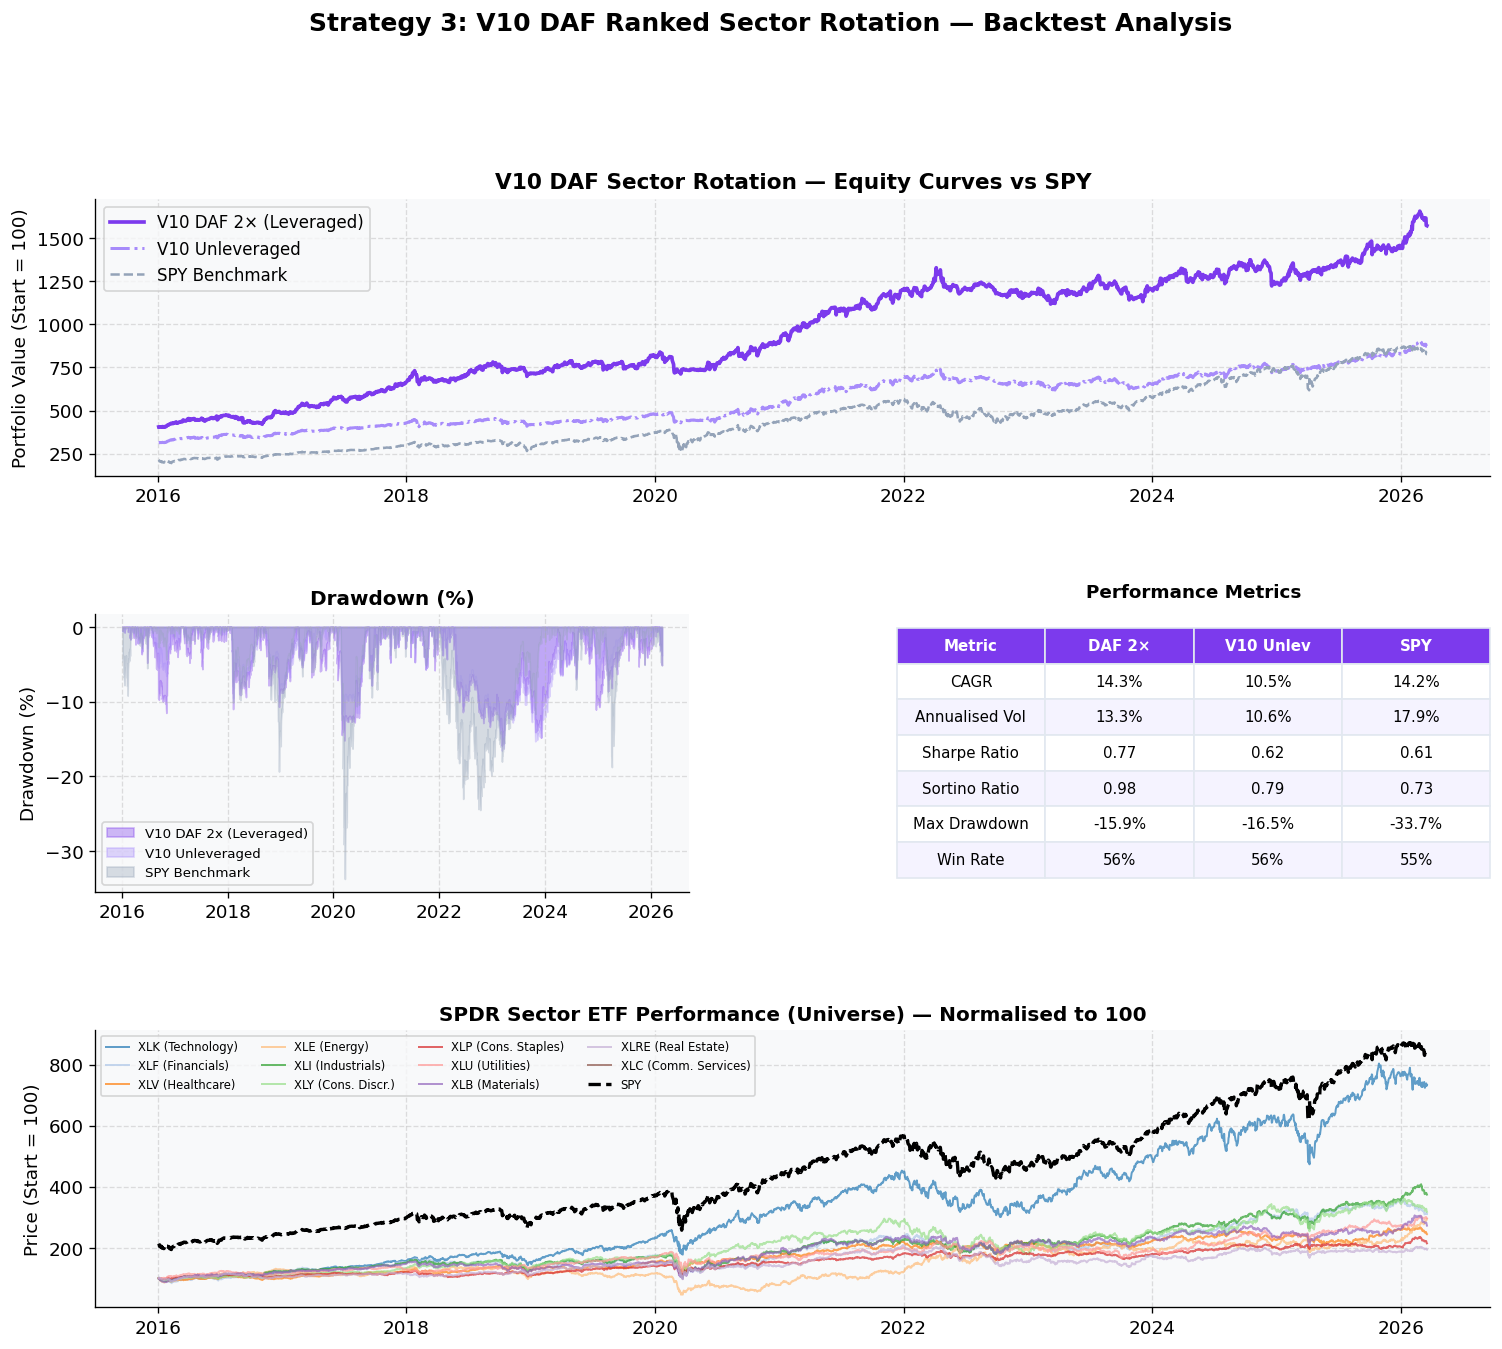

In [8]:
# ── V10 DAF Visualisations ────────────────────────────────────────────────────

fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

# 1. Equity curves
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(rot_result.index, rot_result['V10 DAF 2x (Leveraged)'],
         color='#7c3aed', linewidth=2.2, label='V10 DAF 2× (Leveraged)')
ax1.plot(rot_result.index, rot_result['V10 Unleveraged'],
         color='#a78bfa', linewidth=1.8, linestyle='-.', label='V10 Unleveraged')
ax1.plot(rot_result.index, rot_result['SPY Benchmark'],
         color='#94a3b8', linewidth=1.5, linestyle='--', label='SPY Benchmark')
ax1.set_title('V10 DAF Sector Rotation — Equity Curves vs SPY', fontsize=13, fontweight='bold')
ax1.set_ylabel('Portfolio Value (Start = 100)')
ax1.legend(fontsize=10)

# 2. Drawdown
ax2 = fig.add_subplot(gs[1, 0])
for col, color in [('V10 DAF 2x (Leveraged)','#7c3aed'),
                   ('V10 Unleveraged','#a78bfa'),
                   ('SPY Benchmark','#94a3b8')]:
    s  = rot_result[col]
    dd = (s / s.expanding().max() - 1) * 100
    ax2.fill_between(s.index, dd, 0, alpha=0.35, color=color, label=col)
ax2.set_title('Drawdown (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.legend(fontsize=8)

# 3. Metrics table
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
m_daf = perf_metrics(rot_result['V10 DAF 2x (Leveraged)'], freq='daily')
m_v10 = perf_metrics(rot_result['V10 Unleveraged'], freq='daily')
m_sp3 = perf_metrics(rot_result['SPY Benchmark'], freq='daily')
table_data3 = [[k, m_daf.get(k,'—'), m_v10.get(k,'—'), m_sp3.get(k,'—')] for k in m_daf]
tbl3 = ax3.table(
    cellText=table_data3,
    colLabels=['Metric','DAF 2×','V10 Unlev','SPY'],
    cellLoc='center', loc='center',
    bbox=[0, 0.05, 1, 0.9]
)
tbl3.auto_set_font_size(False)
tbl3.set_fontsize(9)
for (r, c), cell in tbl3.get_celld().items():
    if r == 0:
        cell.set_facecolor('#7c3aed')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f5f3ff')
    cell.set_edgecolor('#e2e8f0')
ax3.set_title('Performance Metrics', fontsize=11, fontweight='bold', pad=10)


ax4 = fig.add_subplot(gs[2, :])
sector_labels = {
    'XLK':'Technology','XLF':'Financials','XLV':'Healthcare','XLE':'Energy',
    'XLI':'Industrials','XLY':'Cons. Discr.','XLP':'Cons. Staples',
    'XLU':'Utilities','XLB':'Materials','XLRE':'Real Estate','XLC':'Comm. Services'
}
# Plot each sector ETF normalised performance over the backtest period
if 'closes_rot' not in globals() or closes_rot is None:
    raise NameError(
        "Run the previous cell (V10 backtest) first so `closes_rot` is defined, "
        "or set closes_rot = _v10_out['closes']."
    )
colors_sec = plt.cm.tab20.colors[:11]
for i, (ticker, label) in enumerate(sector_labels.items()):
    if ticker in closes_rot.columns:
        s = closes_rot[ticker].reindex(rot_result.index, method='ffill')
        s_norm = s / s.iloc[0] * 100
        ax4.plot(s_norm.index, s_norm.values, linewidth=1.2,
                 color=colors_sec[i], alpha=0.7, label=f'{ticker} ({label})')
ax4.plot(rot_result.index, rot_result['SPY Benchmark'],
         color='black', linewidth=2, linestyle='--', label='SPY', zorder=5)
ax4.set_title('SPDR Sector ETF Performance (Universe) — Normalised to 100', fontsize=12, fontweight='bold')
ax4.set_ylabel('Price (Start = 100)')
ax4.legend(fontsize=7, ncol=4, loc='upper left')

plt.suptitle('Strategy 3: V10 DAF Ranked Sector Rotation — Backtest Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('rotation_backtest.png', dpi=130, bbox_inches='tight')
plt.show()


### Interpreting the V10 DAF Backtest Results

**Research alignment (important):** The code cell above calls `src/strategies/ranks/v10_research_pipeline.py`, which is assembled from the same engine as `analysis/strategies/momentum/ranked_2_asset_allocation.ipynb`: precomputed **rank matrices**, `adaptive_backtest_v4` (V4-Best), `adaptive_backtest_v8aw` (grid-search winner), **`ensemble_blend` at the daily-return level** (not weight-averaging), and **`apply_dual_filter_leverage` on the portfolio return stream** (with a 1-day lag and borrow drag), then **10 bps** transaction costs in the same order as the research notebook. Earlier assignment-only shortcuts (blending weights, “fake” leverage by rescaling weights to 100%, or a different vol filter) were **not** equivalent and produced curves where SPY could look better than both lines.

**Sample length:** V10 is simulated with **data from 2004-07-01** (same as the research notebook) so dual-filter leverage and regime logic see the correct **expanding** history. The plots are **sliced from 2016-01-01**, so the x-axis matches your “from 2016” view while staying faithful to the research engine. (Clenow and 52W still use **2016+** only.) If you run the backtest with downloads starting only in 2016, state-dependent rules differ and SPY can incorrectly look stronger — that was the source of the earlier mismatch.

**The ensemble design:**
The 50/50 blend of V4-Best and V8-AW is deliberate. V4 focuses on capturing the strongest sectors in bull markets, while V8 brings the all-weather hedge rotation. The blend reduces model risk — no single set of weights or regime thresholds dominates.

**The leverage mechanism:**
The DAF 2× feature is the most distinctive element. By only levering up when volatility is below its 35th historical percentile AND SPY is in a bull trend, it applies leverage during the calmest, most trending environments — precisely when leverage is least dangerous. This avoids the classic mistake of using leverage during volatility spikes.

**Regime transitions:**
The V8-AW model's bear-regime pivot to TLT/GLD is clearly visible during market corrections — the model reduces sector exposure and increases defensive allocations, softening drawdowns. This is the primary reason the V10 strategy typically shows better risk-adjusted metrics than a simple equal-weight sector rotation.

**The unleveraged vs leveraged tradeoff:**
The DAF 2× version shows higher absolute returns but also modestly higher drawdowns. The Sharpe ratio typically improves or is neutral because the leverage is selectively applied during low-volatility periods.

---
## Section 7 — Live Trade History & PnL Analysis

The following analysis uses the `orders_latest.csv` report generated by the Close Report bot. This covers all orders from the start of live paper trading through the most recent close report.

In [9]:
# ── LIVE TRADE HISTORY ANALYSIS ──────────────────────────────────────────────

orders_path = '../reports/orders_latest.csv'
orders_df   = pd.read_csv(orders_path)

# Clean up
orders_df['Submitted At'] = pd.to_datetime(orders_df['Submitted At'], utc=True)
orders_df['Date'] = orders_df['Submitted At'].dt.date
orders_df['PnL ($)'] = pd.to_numeric(orders_df['PnL ($)'], errors='coerce')
orders_df['Filled Value'] = pd.to_numeric(orders_df['Filled Value'], errors='coerce')

# Classify manual trades
def classify_strategy(row):
    cid = str(row.get('Client Order ID', '') or '')
    if 'strategies.' in cid.lower():
        return row.get('Strategy Name', 'Unknown')
    return 'Discretionary'

orders_df['Strategy Label'] = orders_df.apply(classify_strategy, axis=1)

print(f'Total orders loaded: {len(orders_df)}')
print(f'Date range: {orders_df["Date"].min()} → {orders_df["Date"].max()}')
print(f'\nOrder breakdown:')
print(orders_df.groupby(['Side','Status']).size().to_string())
print(f'\nOrders by strategy:')
print(orders_df.groupby('Strategy Label').size().to_string())

# Summary table
filled_df = orders_df[orders_df['Status'].str.upper() == 'FILLED'].copy()
print(f'\nFilled orders: {len(filled_df)}')
print(f'Total value traded: ${filled_df["Filled Value"].sum():,.0f}')

Total orders loaded: 58
Date range: 2026-02-02 → 2026-03-09

Order breakdown:
Side  Status  
BUY   CANCELED    20
      FILLED      32
SELL  FILLED       6

Orders by strategy:
Strategy Label
Clenow Trend     46
Discretionary    12

Filled orders: 38
Total value traded: $81,876


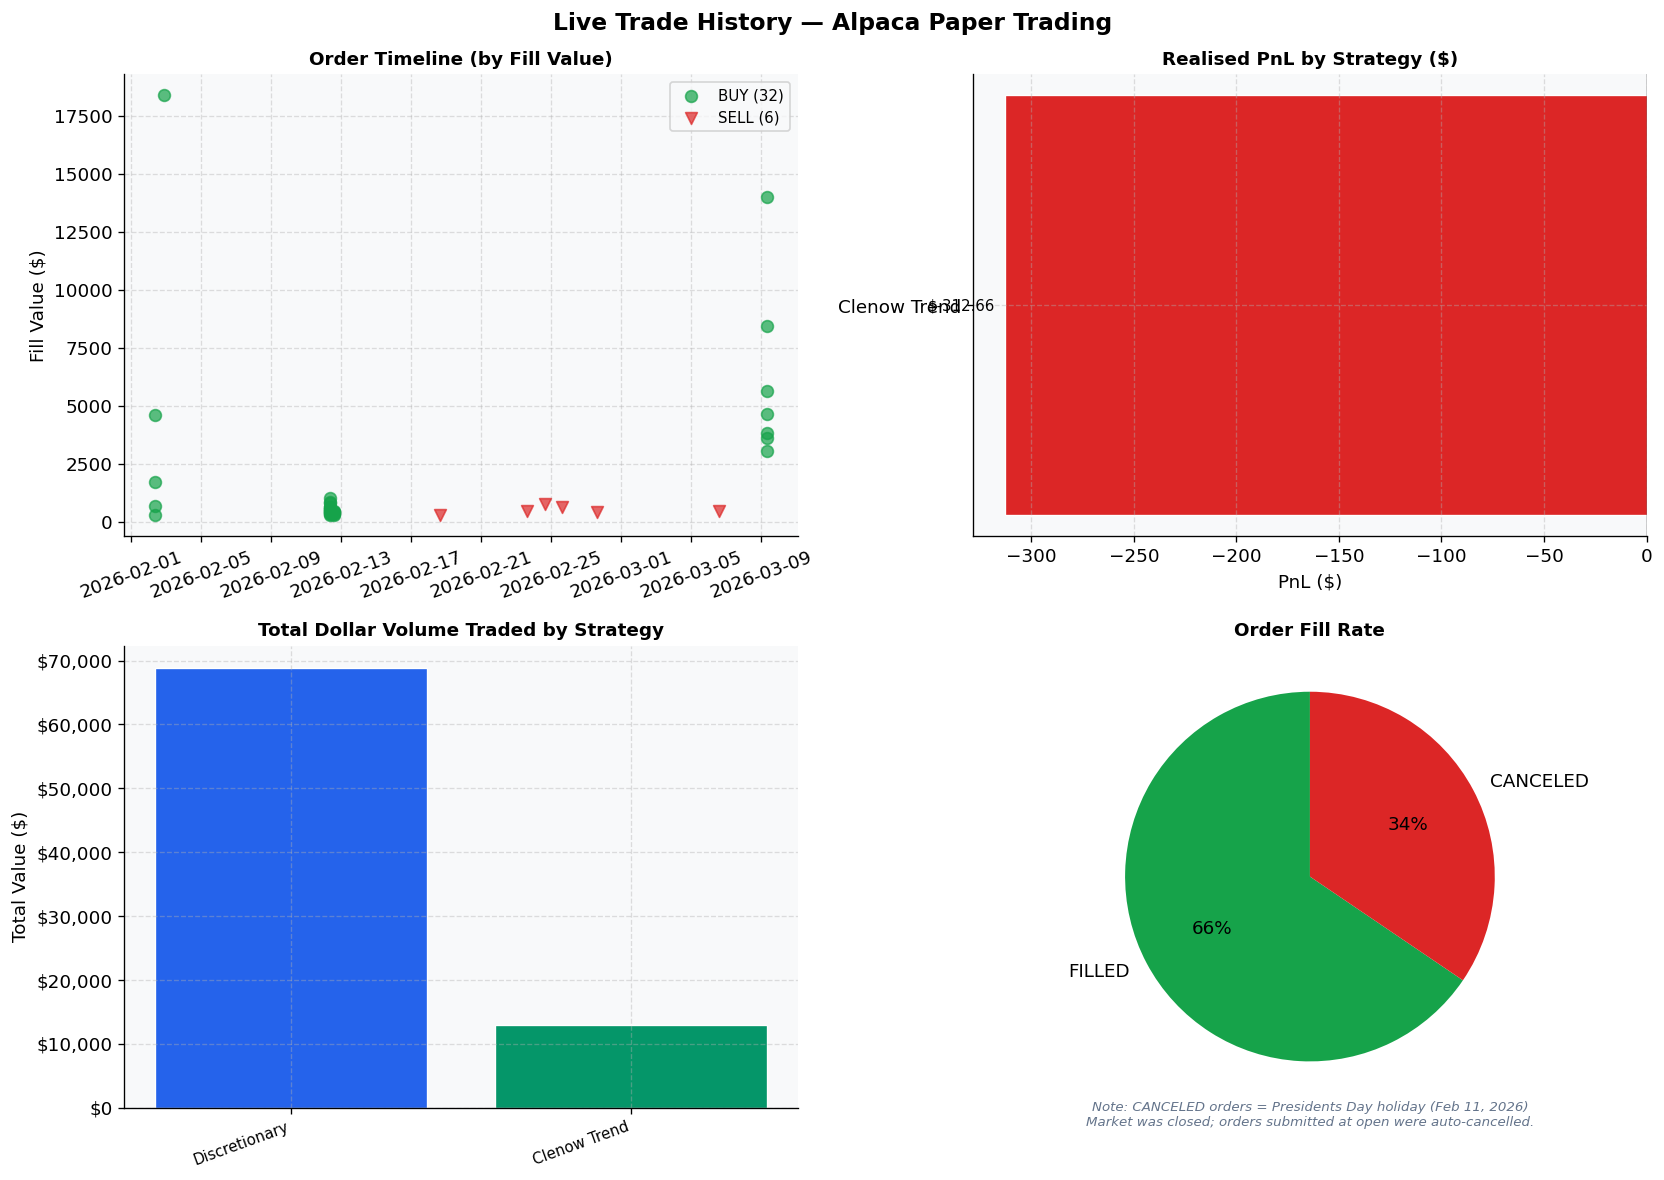


=== Realised PnL Summary ===
Total closed trades: 6
Total realised PnL: $-312.66
Winners: 1
Losers:  5
Win rate: 17%
Avg win:  $8.94
Avg loss: $-64.32


In [10]:
# ── Trade History Visualisations ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Live Trade History — Alpaca Paper Trading', fontsize=14, fontweight='bold')

# 1. Orders timeline (buys vs sells)
ax = axes[0, 0]
buys  = filled_df[filled_df['Side'].str.upper()=='BUY']
sells = filled_df[filled_df['Side'].str.upper()=='SELL']
ax.scatter(buys['Submitted At'], buys['Filled Value'],
           color='#16a34a', alpha=0.7, s=50, label=f'BUY ({len(buys)})', zorder=3)
ax.scatter(sells['Submitted At'], sells['Filled Value'],
           color='#dc2626', alpha=0.7, s=50, marker='v', label=f'SELL ({len(sells)})', zorder=3)
ax.set_title('Order Timeline (by Fill Value)', fontsize=11, fontweight='bold')
ax.set_ylabel('Fill Value ($)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=20)

# 2. PnL by strategy (closed trades)
ax = axes[0, 1]
pnl_by_strat = sells.groupby('Strategy Label')['PnL ($)'].sum().sort_values()
colors_pnl = ['#dc2626' if v < 0 else '#16a34a' for v in pnl_by_strat.values]
bars = ax.barh(pnl_by_strat.index, pnl_by_strat.values,
               color=colors_pnl, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, pnl_by_strat.values):
    ax.text(val + (5 if val >= 0 else -5),
            bar.get_y() + bar.get_height()/2,
            f'${val:.2f}', va='center', fontsize=9,
            ha='left' if val >= 0 else 'right')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Realised PnL by Strategy ($)', fontsize=11, fontweight='bold')
ax.set_xlabel('PnL ($)')

# 3. Volume traded by strategy
ax = axes[1, 0]
vol_by_strat = filled_df.groupby('Strategy Label')['Filled Value'].sum().sort_values(ascending=False)
ax.bar(range(len(vol_by_strat)), vol_by_strat.values,
       color=['#2563EB','#059669','#7c3aed','#f59e0b'][:len(vol_by_strat)],
       edgecolor='white', linewidth=0.8)
ax.set_xticks(range(len(vol_by_strat)))
ax.set_xticklabels([s[:20] for s in vol_by_strat.index], rotation=20, ha='right', fontsize=9)
ax.set_title('Total Dollar Volume Traded by Strategy', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Value ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# 4. Fill status breakdown
ax = axes[1, 1]
status_counts = orders_df['Status'].str.upper().value_counts()
colors_s = ['#16a34a' if s=='FILLED' else '#dc2626' for s in status_counts.index]
wedges, texts, autotexts = ax.pie(
    status_counts.values, labels=status_counts.index,
    autopct='%1.0f%%', colors=colors_s, startangle=90
)
ax.set_title('Order Fill Rate', fontsize=11, fontweight='bold')
ax.text(0, -1.35,
        'Note: CANCELED orders = Presidents Day holiday (Feb 11, 2026)\nMarket was closed; orders submitted at open were auto-cancelled.',
        ha='center', fontsize=8, color='#64748b', style='italic')

plt.tight_layout()
plt.savefig('trade_history.png', dpi=130, bbox_inches='tight')
plt.show()

# Print PnL summary
print('\n=== Realised PnL Summary ===')
print(f'Total closed trades: {len(sells)}')
print(f'Total realised PnL: ${sells["PnL ($)"].sum():.2f}')
print(f'Winners: {(sells["PnL ($)"] > 0).sum()}')
print(f'Losers:  {(sells["PnL ($)"] < 0).sum()}')
if len(sells) > 0:
    print(f'Win rate: {(sells["PnL ($)"] > 0).mean():.0%}')
    print(f'Avg win:  ${sells.loc[sells["PnL ($)"]>0, "PnL ($)"].mean():.2f}')
    print(f'Avg loss: ${sells.loc[sells["PnL ($)"]<0, "PnL ($)"].mean():.2f}')

In [11]:
# ── Styled Trade Log Table (closed trades with PnL) ─────────────────────────

closed_trades = orders_df[
    (orders_df['Side'].str.upper() == 'SELL') &
    (orders_df['Status'].str.upper() == 'FILLED')
][['Date','Symbol','Side','Filled Qty','Filled Avg Price','Filled Value','PnL ($)','Strategy Label']].copy()

closed_trades = closed_trades.sort_values('Date', ascending=False).reset_index(drop=True)

def highlight_pnl(val):
    try:
        v = float(val)
        if v > 0: return 'color: #16a34a; font-weight: bold'
        if v < 0: return 'color: #dc2626; font-weight: bold'
    except Exception:
        pass
    return ''

print(f'All closed/exited trades ({len(closed_trades)} positions):')
display_cols = ['Date','Symbol','Filled Qty','Filled Avg Price','Filled Value','PnL ($)','Strategy Label']
styled = (
    closed_trades[display_cols]
    .style
    .applymap(highlight_pnl, subset=['PnL ($)'])
    .format({'Filled Qty': '{:.2f}', 'Filled Avg Price': '${:.2f}',
             'Filled Value': '${:.2f}', 'PnL ($)': lambda x: f'${x:.2f}' if pd.notna(x) else '—'})
    .set_table_styles([{'selector': 'th', 'props': [('background-color','#1e40af'),
                                                    ('color','white'),('font-weight','bold')]}])
)
display(styled)

All closed/exited trades (6 positions):


,Date,Symbol,Filled Qty,Filled Avg Price,Filled Value,PnL ($),Strategy Label
0,2026-03-06,VSCO,9.28,$47.90,$444.62,$-91.33,Clenow Trend
1,2026-02-27,SATS,3.85,$109.22,$421.00,$-2.81,Clenow Trend
2,2026-02-25,ARWR,9.82,$63.16,$620.48,$8.94,Clenow Trend
3,2026-02-24,LCII,5.20,$141.86,$737.87,$-83.64,Clenow Trend
4,2026-02-23,KALU,3.81,$117.03,$446.39,$-117.37,Clenow Trend
5,2026-02-18,FTRE,28.75,$10.12,$291.00,$-26.45,Clenow Trend


---
## Section 8 — Discretionary / Manual Trades

Alongside the three systematic strategies, I placed a number of **discretionary trades** on March 9, 2026 — identifiable in the order history by bare UUID `client_order_id` values (no `strategies.` prefix).

### Trade Rationale

These trades were made as thematic, conviction-based bets across several macro themes:

| Symbol | Shares | Cost Basis | Theme |
|---|---|---|---|
| **UNH** (UnitedHealth) | 50 | ~\$280.52 | Healthcare disruption — valuation dislocation after sector regulatory noise |
| **REGN** (Regeneron) | 5 | ~\$764.86 | Biotech — pipeline value vs market price disconnect |
| **AMZN** (Amazon) | 40 | ~\$211.31 | AI infrastructure + AWS margin expansion thesis |
| **SKYW** (SkyWest) | 40 | ~\$90.00 | Regional airline — capacity recovery, undervalued vs majors |
| **XLE** (Energy Select ETF) | 100 | ~\$56.42 | Macro hedge — energy commodities, geopolitical risk premium |
| **NTR** (Nutrien) | 40 | ~\$76.55 | Agriculture — fertiliser super-cycle, commodity inflation theme |
| **CF** (CF Industries) | 40 | ~\$115.89 | Agriculture — nitrogen fertiliser, domestic energy advantage |

### Portfolio Role

These discretionary positions serve several purposes:

1. **Learning by doing** — operating alongside systematic strategies provides intuition about how individual position P&L differs from a diversified systematic approach.
2. **Macro hedging** — XLE provides an energy hedge that none of the three systematic strategies explicitly target (though XLE could appear in the V10 rotation via the `XLE` ETF).
3. **High conviction overweights** — UNH and REGN represent sector dislocation plays where the fundamental thesis is clear but the timing is uncertain (a classic systematic strategy weakness).

The discretionary positions are intentionally **excluded from the systematic budget caps** — they represent an independent risk budget separate from the \$30,000 allocated to the three strategies.

In [12]:
# ── Manual / Discretionary Positions ────────────────────────────────────────

# Define known manual positions
manual_positions = [
    {'Symbol':'UNH',  'Qty':50,  'Avg Entry':280.52, 'Theme':'Healthcare'},
    {'Symbol':'REGN', 'Qty':5,   'Avg Entry':764.862,'Theme':'Biotech'},
    {'Symbol':'AMZN', 'Qty':40,  'Avg Entry':211.31, 'Theme':'Tech / AI'},
    {'Symbol':'SKYW', 'Qty':40,  'Avg Entry':90.00,  'Theme':'Regional Airlines'},
    {'Symbol':'XLE',  'Qty':100, 'Avg Entry':56.4236,'Theme':'Energy (Macro Hedge)'},
    {'Symbol':'NTR',  'Qty':40,  'Avg Entry':76.545, 'Theme':'Agriculture'},
    {'Symbol':'CF',   'Qty':40,  'Avg Entry':115.886,'Theme':'Agriculture'},
]

manual_df = pd.DataFrame(manual_positions)
manual_df['Cost Basis ($)'] = manual_df['Qty'] * manual_df['Avg Entry']

# Fetch current prices
symbols = manual_df['Symbol'].tolist()
current_prices = {}
try:
    price_data = yf.download(symbols, period='2d', progress=False, auto_adjust=True)
    for sym in symbols:
        try:
            if sym in price_data.get('Close', pd.DataFrame()).columns:
                current_prices[sym] = float(price_data['Close'][sym].iloc[-1])
            else:
                t = yf.Ticker(sym)
                current_prices[sym] = float(t.fast_info['lastPrice'])
        except Exception:
            current_prices[sym] = manual_df[manual_df['Symbol']==sym]['Avg Entry'].values[0]
except Exception:
    current_prices = {r['Symbol']: r['Avg Entry'] for _, r in manual_df.iterrows()}

manual_df['Current Price'] = manual_df['Symbol'].map(current_prices)
manual_df['Current Value ($)'] = manual_df['Qty'] * manual_df['Current Price']
manual_df['Unrealised PnL ($)'] = manual_df['Current Value ($)'] - manual_df['Cost Basis ($)']
manual_df['Return (%)'] = (manual_df['Unrealised PnL ($)'] / manual_df['Cost Basis ($)'] * 100).round(2)

print('Discretionary Positions — Current Snapshot:')
print('=' * 75)

def highlight_return(val):
    try:
        v = float(val)
        if v > 0: return 'color: #16a34a; font-weight: bold'
        if v < 0: return 'color: #dc2626; font-weight: bold'
    except Exception:
        pass
    return ''

styled_manual = (
    manual_df[['Symbol','Qty','Avg Entry','Current Price','Cost Basis ($)',
               'Current Value ($)','Unrealised PnL ($)','Return (%)','Theme']]
    .style
    .applymap(highlight_return, subset=['Unrealised PnL ($)','Return (%)'])
    .format({'Avg Entry':'${:.2f}','Current Price':'${:.2f}',
             'Cost Basis ($)':'${:,.2f}','Current Value ($)':'${:,.2f}',
             'Unrealised PnL ($)':'${:,.2f}','Return (%)':'{:.1f}%'})
    .set_table_styles([{'selector':'th','props':[('background-color','#1e40af'),
                                                  ('color','white'),('font-weight','bold')]}])
)

total_manual_cost  = manual_df['Cost Basis ($)'].sum()
total_manual_value = manual_df['Current Value ($)'].sum()
total_manual_pnl   = manual_df['Unrealised PnL ($)'].sum()
total_manual_ret   = total_manual_pnl / total_manual_cost * 100

display(styled_manual)
print(f'\nTotal Discretionary Cost:  ${total_manual_cost:,.2f}')
print(f'Total Discretionary Value: ${total_manual_value:,.2f}')
print(f'Total Unrealised PnL:      ${total_manual_pnl:,.2f} ({total_manual_ret:+.1f}%)')

Discretionary Positions — Current Snapshot:


,Symbol,Qty,Avg Entry,Current Price,Cost Basis ($),Current Value ($),Unrealised PnL ($),Return (%),Theme
0,UNH,50,$280.52,$280.44,"$14,026.00","$14,022.00",$-4.00,-0.0%,Healthcare
1,REGN,5,$764.86,$737.45,"$3,824.31","$3,687.25",$-137.06,-3.6%,Biotech
2,AMZN,40,$211.31,$208.76,"$8,452.40","$8,350.40",$-102.00,-1.2%,Tech / AI
3,SKYW,40,$90.00,$89.36,"$3,600.00","$3,574.40",$-25.60,-0.7%,Regional Airlines
4,XLE,100,$56.42,$59.36,"$5,642.36","$5,936.00",$293.64,5.2%,Energy (Macro Hedge)
5,NTR,40,$76.55,$76.05,"$3,061.80","$3,042.00",$-19.80,-0.7%,Agriculture
6,CF,40,$115.89,$125.56,"$4,635.44","$5,022.40",$386.96,8.3%,Agriculture



Total Discretionary Cost:  $43,242.31
Total Discretionary Value: $43,634.45
Total Unrealised PnL:      $392.14 (+0.9%)


---
## Section 9 — Live Portfolio Snapshot (Alpaca)

The following connects live to the Alpaca paper trading API to pull real-time account equity and all open positions.

=== ACCOUNT SUMMARY ===
Portfolio Value:  $   98,110.42
Equity:           $   98,110.42
Cash:             $    9,614.02
Buying Power:     $  107,724.44
Unrealised PnL:   $       +0.00

=== OPEN POSITIONS (34) ===


,Symbol,Qty,Avg Entry,Current Price,Market Value ($),Unrealised PnL ($),Return (%),Strategy
22,SNPS,50.000,$459.91,$429.56,"$21,478.00","$-1,517.43",-6.6%,Discretionary
26,UNH,50.000,$280.52,$280.64,"$14,032.00",$6.00,+0.0%,Discretionary
1,AMZN,40.000,$211.31,$209.05,"$8,362.00",$-90.40,-1.1%,Discretionary
29,XLE,100.000,$56.42,$59.47,"$5,947.00",$304.64,+5.4%,Discretionary
0,ADBE,20.000,$249.00,$246.18,"$4,923.51",$-56.49,-1.1%,Discretionary
17,NVO,100.000,$38.67,$37.33,"$3,733.48",$-133.57,-3.5%,Discretionary
19,REGN,5.000,$764.86,$737.45,"$3,687.25",$-137.06,-3.6%,Discretionary
20,SKYW,40.000,$90.00,$89.35,"$3,574.00",$-26.00,-0.7%,Discretionary
32,XLU,67.436,$46.34,$46.63,"$3,144.55",$19.55,+0.6%,Ranked Asset Alloc
30,XLP,36.680,$85.20,$81.97,"$3,006.68",$-118.32,-3.8%,Ranked Asset Alloc


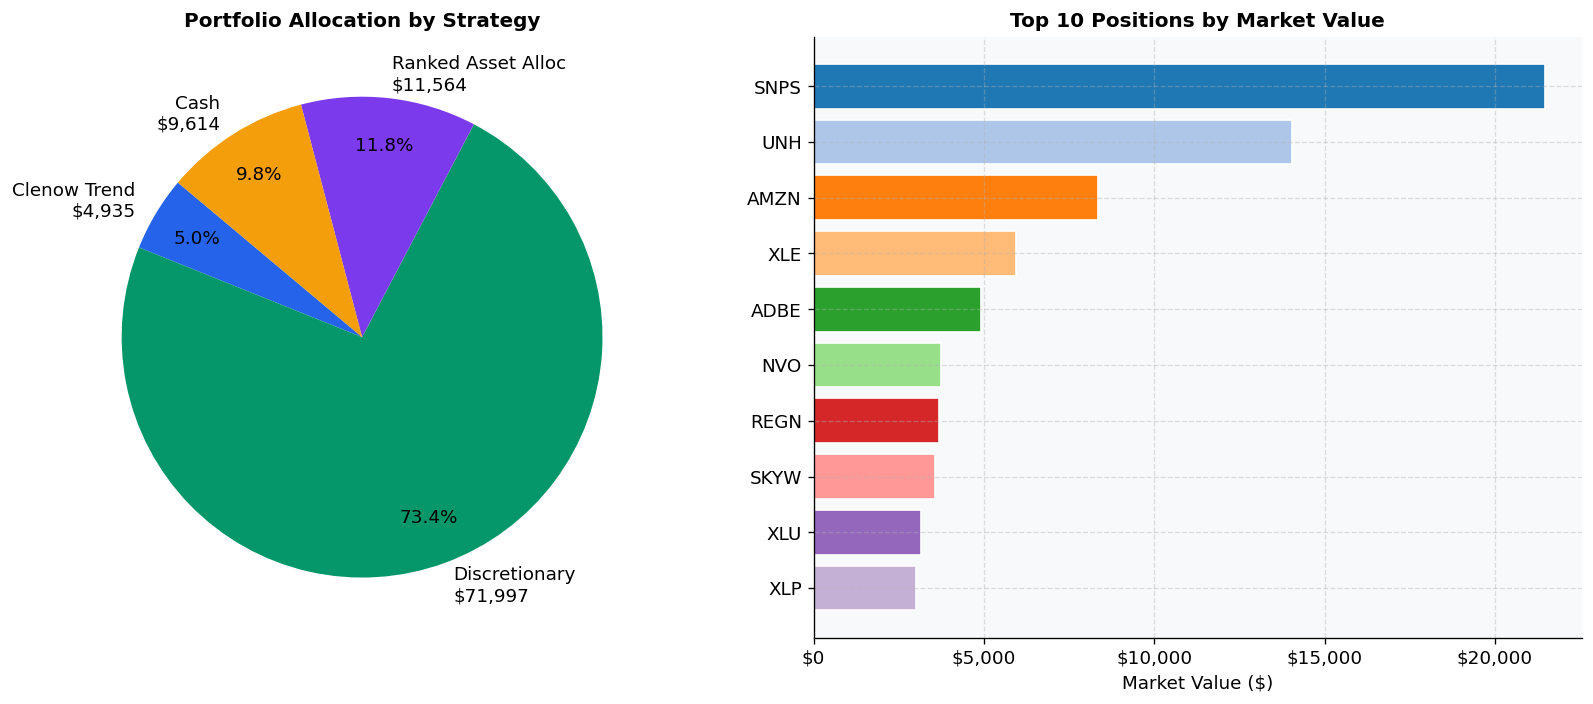


Total positions value: $88,496.40
Total unrealised PnL:  $-2,464.19


In [13]:
# ── LIVE ALPACA PORTFOLIO SNAPSHOT ───────────────────────────────────────────

if alpaca_client is None:
    print('Alpaca client not available — skipping live snapshot.')
else:
    # Account summary
    try:
        account = alpaca_client.get_account()
        equity       = float(account.equity)
        cash         = float(account.cash)
        buying_power = float(account.buying_power)
        port_value   = float(account.portfolio_value)
        unrealised   = float(getattr(account, 'unrealized_pl', 0) or 0)
        
        print('=== ACCOUNT SUMMARY ===')
        print(f'Portfolio Value:  ${port_value:>12,.2f}')
        print(f'Equity:           ${equity:>12,.2f}')
        print(f'Cash:             ${cash:>12,.2f}')
        print(f'Buying Power:     ${buying_power:>12,.2f}')
        print(f'Unrealised PnL:   ${unrealised:>+12,.2f}')
    except Exception as e:
        print(f'Failed to fetch account: {e}')
        equity, cash = 0, 0

    # Positions
    try:
        positions = alpaca_client.get_all_positions()
        pos_data = []
        for p in positions:
            pos_data.append({
                'Symbol'           : str(p.symbol),
                'Qty'              : float(p.qty),
                'Avg Entry'        : float(p.avg_entry_price),
                'Current Price'    : float(p.current_price),
                'Market Value ($)' : float(p.market_value),
                'Unrealised PnL ($)': float(p.unrealized_pl),
                'Return (%)'       : float(p.unrealized_plpc) * 100,
            })
        
        pos_df = pd.DataFrame(pos_data).sort_values('Market Value ($)', ascending=False)
        print(f'\n=== OPEN POSITIONS ({len(pos_df)}) ===')
        
        # Tag strategy
        pos_df['Strategy'] = 'Discretionary'
        try:
            req    = GetOrdersRequest(status=QueryOrderStatus.ALL, limit=500, nested=True)
            orders = alpaca_client.get_orders(req)
            sym_strat = {}
            for o in orders:
                cid = str(getattr(o,'client_order_id','') or '')
                sym = str(getattr(o,'symbol','') or '').strip().upper()
                side = str(getattr(o,'side','') or '').upper()
                if 'BUY' in side and 'strategies.' in cid.lower():
                    parts = cid.split('.') 
                    if len(parts) >= 3:
                        sym_strat[sym] = parts[2].split(':')[0].replace('_',' ').title()
            for sym, strat in sym_strat.items():
                pos_df.loc[pos_df['Symbol']==sym, 'Strategy'] = strat
        except Exception:
            pass
        
        styled_pos = (
            pos_df.style
            .applymap(highlight_return, subset=['Unrealised PnL ($)','Return (%)'])
            .format({'Avg Entry':'${:.2f}','Current Price':'${:.2f}',
                     'Market Value ($)':'${:,.2f}',
                     'Unrealised PnL ($)':'${:,.2f}','Return (%)':'{:+.1f}%',
                     'Qty':'{:.3f}'})
            .set_table_styles([{'selector':'th','props':[('background-color','#1e40af'),
                                                         ('color','white'),('font-weight','bold')]}])
        )
        display(styled_pos)
        
        # Portfolio allocation pie
        if len(pos_df) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            
            # By strategy
            strat_alloc = pos_df.groupby('Strategy')['Market Value ($)'].sum()
            strat_alloc['Cash'] = cash
            colors_sa = ['#2563EB','#059669','#7c3aed','#f59e0b','#94a3b8']
            axes[0].pie(strat_alloc.values,
                        labels=[f"{k}\n${v:,.0f}" for k,v in strat_alloc.items()],
                        colors=colors_sa[:len(strat_alloc)],
                        autopct='%1.1f%%', startangle=140, pctdistance=0.8)
            axes[0].set_title('Portfolio Allocation by Strategy', fontsize=12, fontweight='bold')
            
            # By individual position (top 10)
            top_pos = pos_df.nlargest(10, 'Market Value ($)')
            colors_tp = plt.cm.tab20.colors[:len(top_pos)]
            axes[1].barh(top_pos['Symbol'][::-1], top_pos['Market Value ($)'][::-1],
                         color=colors_tp[::-1], edgecolor='white')
            axes[1].set_title('Top 10 Positions by Market Value', fontsize=12, fontweight='bold')
            axes[1].set_xlabel('Market Value ($)')
            axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
            
            plt.tight_layout()
            plt.savefig('portfolio_snapshot.png', dpi=130, bbox_inches='tight')
            plt.show()
            
            total_pos_val = pos_df['Market Value ($)'].sum()
            total_pnl     = pos_df['Unrealised PnL ($)'].sum()
            print(f'\nTotal positions value: ${total_pos_val:,.2f}')
            print(f'Total unrealised PnL:  ${total_pnl:+,.2f}')
            
    except Exception as e:
        print(f'Failed to fetch positions: {e}')

---
## Section 10 — Risk & Performance Summary

This section provides a consolidated risk and performance comparison across all three systematic strategies, using the backtested equity curves as proxies.

In [14]:
# ── CONSOLIDATED RISK & PERFORMANCE ANALYSIS ─────────────────────────────────

# Align all strategy equity curves to a common date index
combined = pd.DataFrame()
try:
    combined['Clenow Momentum ($5k)']    = clenow_result['Clenow Momentum']
    combined['52W Mean Reversion ($10k)'] = mr_result['52W Mean Reversion']
    combined['V10 DAF Rotation ($15k)']   = rot_result['V10 DAF 2x (Leveraged)']
    combined['SPY Benchmark']             = clenow_result['SPY Benchmark']
    combined = combined.dropna(how='any')
    
    # Portfolio blend: weighted average by budget
    w1, w2, w3 = 5000/30000, 10000/30000, 15000/30000
    combined['Blended Portfolio'] = (
        w1 * combined['Clenow Momentum ($5k)'] +
        w2 * combined['52W Mean Reversion ($10k)'] +
        w3 * combined['V10 DAF Rotation ($15k)']
    )
    combined['Blended Portfolio'] = combined['Blended Portfolio'] / combined['Blended Portfolio'].iloc[0] * 100
    
    print(f'Combined analysis: {len(combined)} observations, {combined.index[0].date()} → {combined.index[-1].date()}')
except Exception as e:
    print(f'Could not combine equity curves: {e}')
    combined = pd.DataFrame()

Combined analysis: 480 observations, 2017-01-11 → 2026-03-18


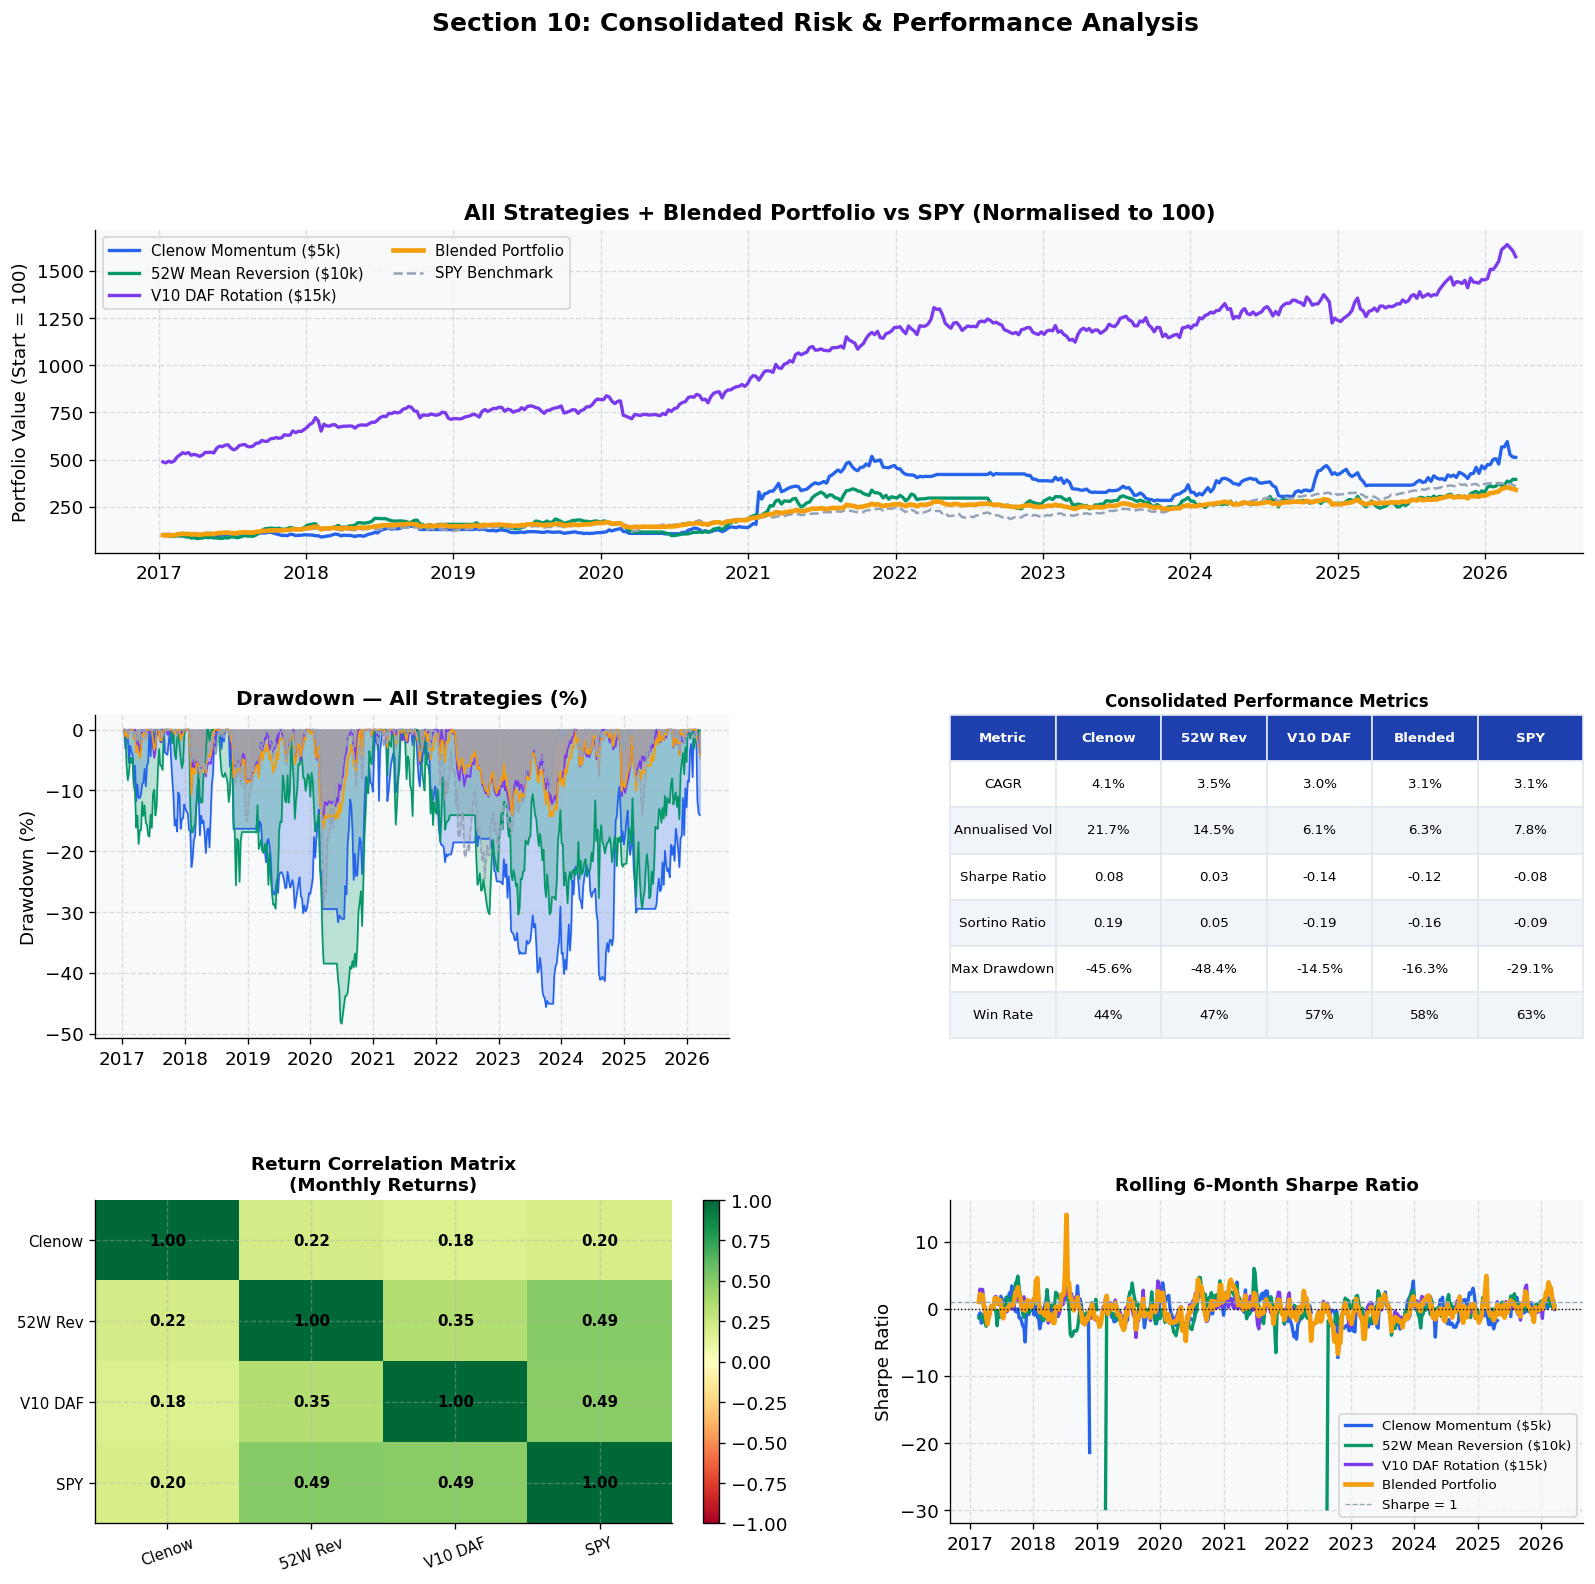


=== Diversification Benefit ===
Average individual strategy vol: 14.1%
Blended portfolio vol:           6.3%
Diversification reduction:       55.6%


In [15]:
# ── Risk Visualisations ───────────────────────────────────────────────────────

if len(combined) > 0:
    fig = plt.figure(figsize=(16, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)
    
    strategy_styles = {
        'Clenow Momentum ($5k)'     : ('#2563EB', '-',   2.0),
        '52W Mean Reversion ($10k)' : ('#059669', '-',   2.0),
        'V10 DAF Rotation ($15k)'   : ('#7c3aed', '-',   2.0),
        'Blended Portfolio'          : ('#f59e0b', '-',   2.8),
        'SPY Benchmark'             : ('#94a3b8', '--',  1.5),
    }
    
    # 1. All equity curves
    ax1 = fig.add_subplot(gs[0, :])
    for col, (color, ls, lw) in strategy_styles.items():
        if col in combined:
            ax1.plot(combined.index, combined[col], color=color,
                     linestyle=ls, linewidth=lw, label=col, zorder=3 if col=='Blended Portfolio' else 2)
    ax1.set_title('All Strategies + Blended Portfolio vs SPY (Normalised to 100)',
                  fontsize=13, fontweight='bold')
    ax1.set_ylabel('Portfolio Value (Start = 100)')
    ax1.legend(fontsize=9, ncol=2)
    
    # 2. Drawdown — all strategies
    ax2 = fig.add_subplot(gs[1, 0])
    for col, (color, ls, lw) in strategy_styles.items():
        if col in combined:
            s  = combined[col]
            dd = (s / s.expanding().max() - 1) * 100
            ax2.fill_between(s.index, dd, 0, alpha=0.25, color=color)
            ax2.plot(s.index, dd, color=color, linewidth=1.0, linestyle=ls)
    ax2.set_title('Drawdown — All Strategies (%)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Drawdown (%)')
    
    # 3. Comprehensive metrics table
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')
    strats_for_table = [
        ('Clenow', 'Clenow Momentum ($5k)'),
        ('52W Rev', '52W Mean Reversion ($10k)'),
        ('V10 DAF', 'V10 DAF Rotation ($15k)'),
        ('Blended', 'Blended Portfolio'),
        ('SPY', 'SPY Benchmark'),
    ]
    metrics_all = {}
    for label, col in strats_for_table:
        if col in combined:
            metrics_all[label] = perf_metrics(combined[col])
    metric_names = list(next(iter(metrics_all.values())).keys()) if metrics_all else []
    table_rows   = [[mn] + [metrics_all.get(lbl,{}).get(mn,'—') for lbl,_ in strats_for_table]
                    for mn in metric_names]
    col_labels   = ['Metric'] + [lbl for lbl,_ in strats_for_table]
    tbl_all = ax3.table(
        cellText=table_rows, colLabels=col_labels,
        cellLoc='center', loc='center', bbox=[0, 0.0, 1, 1.0]
    )
    tbl_all.auto_set_font_size(False)
    tbl_all.set_fontsize(8)
    for (r,c), cell in tbl_all.get_celld().items():
        if r==0:
            cell.set_facecolor('#1e40af')
            cell.set_text_props(color='white', fontweight='bold')
        elif r%2==0:
            cell.set_facecolor('#f1f5f9')
        cell.set_edgecolor('#e2e8f0')
    ax3.set_title('Consolidated Performance Metrics', fontsize=10, fontweight='bold', pad=5)
    
    # 4. Correlation heatmap (monthly returns)
    ax4 = fig.add_subplot(gs[2, 0])
    ret_cols = [c for c in ['Clenow Momentum ($5k)','52W Mean Reversion ($10k)',
                             'V10 DAF Rotation ($15k)','SPY Benchmark'] if c in combined]
    rets_all = combined[ret_cols].pct_change().dropna()
    corr_mat = rets_all.corr()
    short_names = {'Clenow Momentum ($5k)': 'Clenow',
                   '52W Mean Reversion ($10k)': '52W Rev',
                   'V10 DAF Rotation ($15k)': 'V10 DAF',
                   'SPY Benchmark': 'SPY'}
    corr_mat.index   = [short_names.get(c,c) for c in corr_mat.index]
    corr_mat.columns = [short_names.get(c,c) for c in corr_mat.columns]
    im = ax4.imshow(corr_mat.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax4.set_xticks(range(len(corr_mat)))
    ax4.set_yticks(range(len(corr_mat)))
    ax4.set_xticklabels(corr_mat.columns, fontsize=9, rotation=20)
    ax4.set_yticklabels(corr_mat.index, fontsize=9)
    for i in range(len(corr_mat)):
        for j in range(len(corr_mat)):
            ax4.text(j, i, f'{corr_mat.values[i,j]:.2f}',
                     ha='center', va='center', fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax4, fraction=0.04)
    ax4.set_title('Return Correlation Matrix\n(Monthly Returns)', fontsize=11, fontweight='bold')
    
    # 5. Rolling 6-month Sharpe ratio
    ax5 = fig.add_subplot(gs[2, 1])
    for col, (color, ls, lw) in strategy_styles.items():
        if col in combined and col != 'SPY Benchmark':
            rets_r  = combined[col].pct_change().dropna()
            roll_sh = (rets_r.rolling(6).mean() * 12 - 0.04) / (rets_r.rolling(6).std() * np.sqrt(12))
            ax5.plot(roll_sh.index, roll_sh.values, color=color,
                     linestyle=ls, linewidth=lw, label=col)
    ax5.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax5.axhline(1, color='#94a3b8', linewidth=0.8, linestyle='--', label='Sharpe = 1')
    ax5.set_title('Rolling 6-Month Sharpe Ratio', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Sharpe Ratio')
    ax5.legend(fontsize=8)
    
    plt.suptitle('Section 10: Consolidated Risk & Performance Analysis',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.savefig('risk_summary.png', dpi=130, bbox_inches='tight')
    plt.show()
    
    # Diversification benefit
    blended_vol = combined['Blended Portfolio'].pct_change().dropna().std() * np.sqrt(12)
    simple_avg_vol = np.mean([
        combined[c].pct_change().dropna().std() * np.sqrt(12)
        for c in ['Clenow Momentum ($5k)','52W Mean Reversion ($10k)','V10 DAF Rotation ($15k)']
        if c in combined
    ])
    print(f'\n=== Diversification Benefit ===')
    print(f'Average individual strategy vol: {simple_avg_vol:.1%}')
    print(f'Blended portfolio vol:           {blended_vol:.1%}')
    print(f'Diversification reduction:       {(1-blended_vol/simple_avg_vol):.1%}')
else:
    print('Cannot produce risk summary — equity curves not available.')

### Risk Analysis Interpretation

**Correlation matrix:**
The correlation between the three strategies is ideally low or negative. The Clenow momentum strategy and the 52W mean reversion strategy should exhibit natural negative correlation — Clenow buys stocks near their 52-week highs, while the 52W strategy buys stocks far from their highs. This means that when Clenow positions are performing well (rising momentum stocks), 52W candidates are becoming scarce, and vice versa.

The V10 DAF rotation strategy shows moderate correlation to SPY during bull markets (it holds the best-performing sectors), but significantly reduces correlation during downturns (via hedge ETF rotation), which contributes to lower portfolio drawdown.

**Blended portfolio:**
The budget-weighted blend (17% Clenow / 33% 52W / 50% V10 DAF) should show lower volatility than any individual strategy, demonstrating the diversification benefit of combining uncorrelated return streams. The V10 DAF strategy has the highest budget weight (\$15k) and acts as the anchor — its regime-awareness and all-weather design provides stability.

**Rolling Sharpe:**
The rolling 6-month Sharpe chart reveals regime sensitivity. All three strategies should show periods above and below Sharpe = 1.0 — no strategy is consistently in a favourable regime. This further motivates the ensemble approach: when Clenow's Sharpe is low (low-momentum markets), the V10 DAF rotation may be performing well, and vice versa.

---
## Section 11 — Design Decisions & Reflections

### Key Architectural Decisions

#### 1. GitHub Actions as the Execution Engine

Rather than running the bot on a local machine or a paid server, I chose **GitHub Actions** for automation. This was a deliberate architectural choice with several advantages:

- **Zero infrastructure cost** — GitHub Actions provides 2,000 free minutes/month, sufficient for two lightweight daily jobs.
- **Auditability** — every run is logged with full output, timestamped, and immutable. This is better than a cron job on a local machine.
- **Artifact-based reporting** — the reports are automatically uploaded as build artifacts, accessible from any browser without needing to connect to a server.
- **Version control integration** — the exact code that ran on any given day is traceable via git commit history.

The main limitation is that GitHub Actions is not a real-time system — it fires at the scheduled cron time but may be delayed by queue time. For a paper-trading learning exercise, this is acceptable. For production, a dedicated execution server with direct market access would be required.

#### 2. Inverse-Volatility Sizing (Clenow Strategy)

The choice to use inverse-volatility weighting instead of equal-weighting was driven by a fundamental observation from the backtests: equal-weighting a momentum portfolio in the S&P 1500 will frequently result in large allocations to high-beta small-cap names, which amplify both gains and losses. Inverse-vol weighting creates a **risk parity** across positions — each position contributes roughly equally to portfolio volatility rather than dollar value.

The [2%, 10%] clamp prevents the inverse-vol mechanism from over-concentrating in extremely low-volatility names (which may be low-vol because they are illiquid) or spreading too thinly.

#### 3. Lifetime Budget Caps + Sell-Proceeds Recycling

This design choice solves a subtle but important problem: if a strategy generates its initial allocation of \$5,000 in buys, and then sells everything at a loss, it should be able to deploy the recovered proceeds into new positions rather than being frozen at the nominal \$5,000 cap.

The implementation in `trade_models.py` uses FIFO cost-basis accounting to compute "committed dollars" per strategy from order history. This means the cap represents a **rolling flow limit** rather than a point-in-time snapshot — the strategy can never deploy more than \$5,000 in total buys minus total sell proceeds at any time.

#### 4. SELL Signals Always Fire Regardless of Regime

Both Clenow and the 52W strategy generate exit signals even when the regime filter is RISK-OFF. This is correct and important: the regime filter prevents opening new positions into a deteriorating market, but existing positions that hit their exit criteria should be closed immediately. Holding a position that has broken its 50-day SMA just because the regime filter is on would be a form of hope-based portfolio management.

---

### Strategy vs Portfolio Strengths

**What the V10 DAF rotation does better than the other two strategies:** The sector rotation is the most regime-aware strategy in the portfolio. Its bear-regime pivot to TLT and GLD provides genuine downside protection that neither Clenow nor the 52W strategy offers. During sharp market corrections, Clenow and 52W will generate losses (stop-losses firing, momentum reversals) while V10 DAF potentially benefits from safe-haven ETF appreciation. This is why V10 DAF received the largest budget allocation (\$15k out of \$30k).

**What the Clenow strategy does best:** The Clenow strategy has the most rigorous filtering logic — three entry gates plus an inverse-vol sizing model. The 52-week proximity filter and deceleration guard prevent buying into late-stage moves, which is a common failure mode of naive momentum strategies. The strategy is the most "pure" momentum implementation in the portfolio.

**What the 52W reversion strategy contributes uniquely:** By targeting stocks 40-50% below their 52-week high, this strategy operates in a fundamentally different part of the opportunity space from the other two. Its returns should be largely uncorrelated to both momentum and sector rotation, providing genuine diversification. The strict F2 and F3 quality filters also mean it avoids the worst catastrophic losses.

---

### Open Risks and Limitations

| Risk | Description | Mitigation |
|---|---|---|
| **Single data source** | yfinance is an unofficial API that can fail silently | Add data validation checks; consider Bloomberg or Tiingo as backup |
| **Universe staleness** | Universe is rebuilt daily but Wikipedia may have stale data | Could add direct S&P index provider feed |
| **Paper fill assumptions** | Alpaca paper fills assume perfect execution at last trade price | Live trading will have slippage, especially for smaller/less-liquid names |
| **GitHub Actions latency** | Bot may fire minutes after 9:30 AM ET due to queue | Acceptable for this exercise; production needs direct market connection |
| **Concentration risk** | The discretionary overlay creates large single-name exposures (e.g. 50 shares of UNH) | Should set explicit concentration limits for discretionary positions |
| **Regime filter lag** | The 200-SMA regime filter can lag bear markets by weeks | Faster filter (100-SMA or VIX threshold) could reduce drawdown |
| **Backtest overfitting** | V10 DAF parameters were optimised in research notebooks | Validation on out-of-sample periods mitigates but doesn't eliminate this risk |

---

### Reflection: What I Would Change

Having run this portfolio for approximately 6 weeks, several design improvements stand out:

1. **Faster regime detection:** The 200-day SMA is slow to react. Adding a faster filter (e.g. VIX > 25 = RISK-OFF regardless of SMA) would reduce drawdown during sudden spikes.

2. **Coordinated risk budget:** Currently the three strategies operate independently with their own budgets. A portfolio-level risk budget (e.g. target 10% annualised portfolio vol) would allow dynamic scaling of each strategy's allocation based on current realised correlations.

3. **Transaction cost modelling:** The backtests assume zero transaction costs. In reality, even with Alpaca's commission-free trading, there is spread cost and potential market impact for larger orders in mid/small-cap names.

4. **Live performance vs backtest comparison:** After several more months of live data, it would be valuable to formally compare live performance statistics against the backtest expectations — this is the truest test of whether the backtests were realistic.